# BMDS2003 Data Science — Combined Notebook
## Online Gaming Behaviour Dataset — Full CRISP-DM Pipeline

This notebook combines all project notebooks (Sections 3.0–6.0) into a single file.
No cell content, code, data, tables, or figures have been altered from the original
individual notebooks — this is a direct concatenation for submission purposes.

**Contents:**
1. 3.0 Data Understanding
2. 4.0 Data Preparation
3. 5.1 Logistic Regression (Baseline)
4. 5.2 Decision Tree Classifier
5. 5.3 Random Forest Classifier
6. 5.4 Gradient Boosting Classifier
7. 6.0 Evaluation

---
---
# 3.0 Data Understanding
---

In [1]:
import pandas as pd

df = pd.read_csv("online_gaming_behavior_dataset.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  str    
 3   Location                   40034 non-null  str    
 4   GameGenre                  40034 non-null  str    
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  str    
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  str    
dtypes: float64(1), int64(7), str(5)
memory usage: 4.9 MB


In [2]:
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [3]:
df.tail()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
40029,49029,32,Male,USA,Strategy,20.619662,0,Easy,4,75,85,14,Medium
40030,49030,44,Female,Other,Simulation,13.539280,0,Hard,19,114,71,27,High
40031,49031,15,Female,USA,RPG,0.240057,1,Easy,10,176,29,1,High
40032,49032,34,Male,USA,Sports,14.017818,1,Medium,3,128,70,10,Medium
40033,49033,19,Male,USA,Sports,10.083804,0,Easy,13,84,72,39,Medium


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  str    
 3   Location                   40034 non-null  str    
 4   GameGenre                  40034 non-null  str    
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  str    
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  str    
dtypes: float64(1), int64(7), str(5)
memory usage: 4.9 MB


In [5]:
df.describe()

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


In [6]:
df.describe(include="object")

C:\Users\yuzhe\AppData\Local\Temp\ipykernel_14548\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Gender,Location,GameGenre,GameDifficulty,EngagementLevel
count,40034,40034,40034,40034,40034
unique,2,4,5,3,3
top,Male,USA,Sports,Easy,Medium
freq,23959,16000,8048,20015,19374


In [7]:
print(df["Gender"].value_counts())
print()
print(df["Location"].value_counts())
print()
print(df["GameGenre"].value_counts())
print()
print(df["GameDifficulty"].value_counts())
print()
print(df["EngagementLevel"].value_counts())

Gender
Male      23959
Female    16075
Name: count, dtype: int64

Location
USA       16000
Europe    12004
Asia       8095
Other      3935
Name: count, dtype: int64

GameGenre
Sports        8048
Action        8039
Strategy      8012
Simulation    7983
RPG           7952
Name: count, dtype: int64

GameDifficulty
Easy      20015
Medium    12011
Hard       8008
Name: count, dtype: int64

EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64


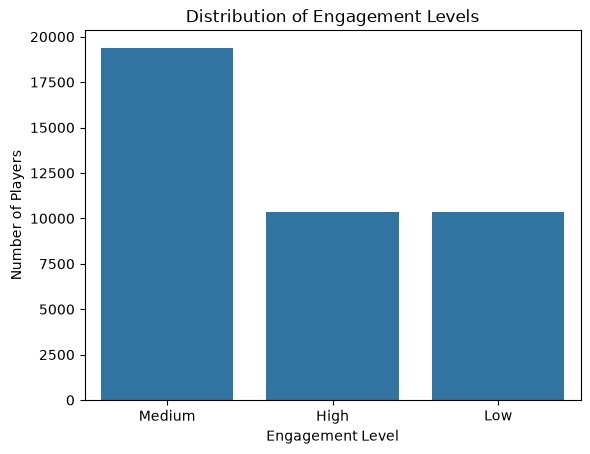

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="EngagementLevel")
plt.title("Distribution of Engagement Levels")
plt.xlabel("Engagement Level")
plt.ylabel("Number of Players")
plt.show()

In [9]:
df["EngagementLevel"].value_counts(normalize=True) * 100

EngagementLevel
Medium    48.393865
High      25.818055
Low       25.788080
Name: proportion, dtype: float64

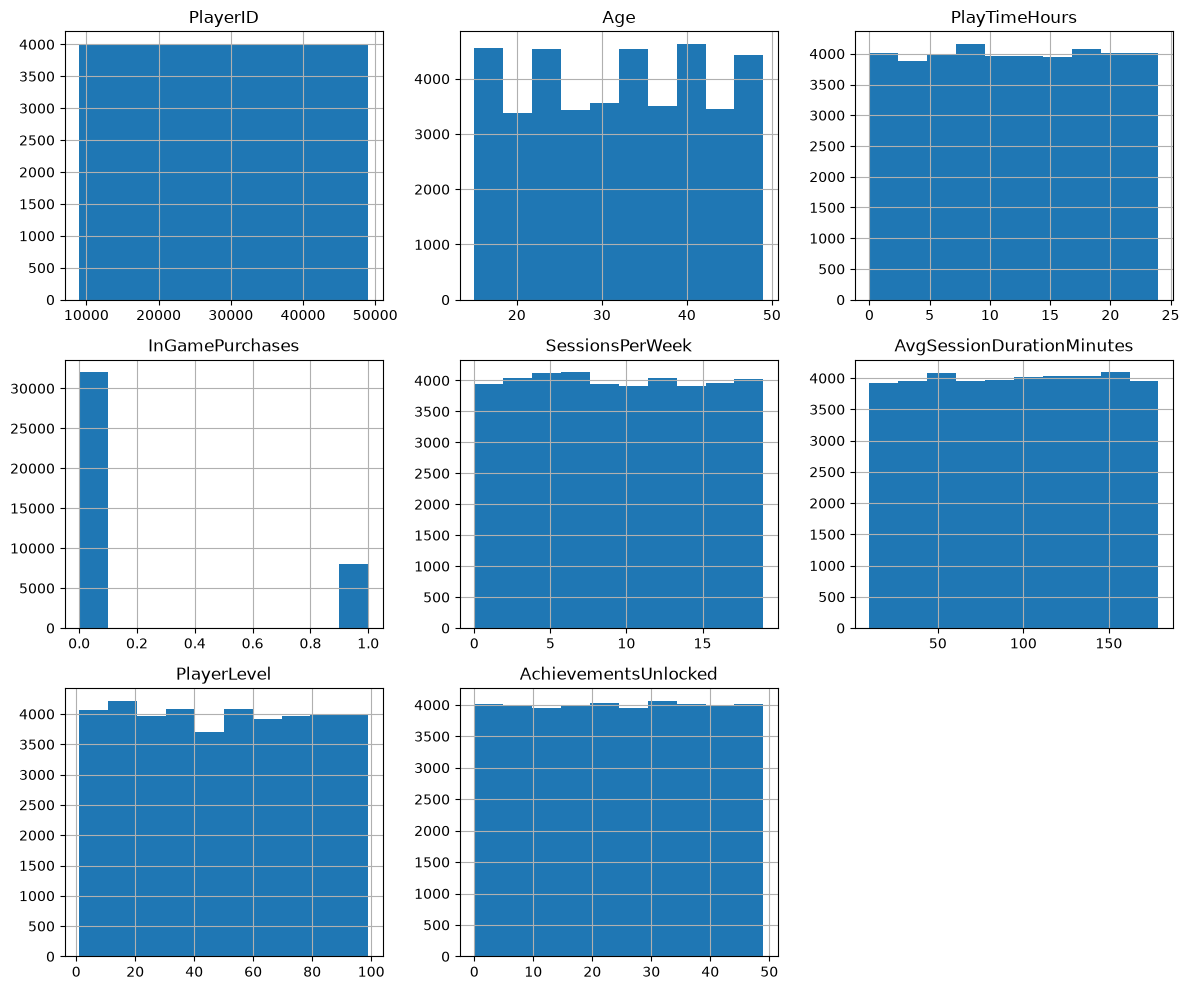

In [10]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

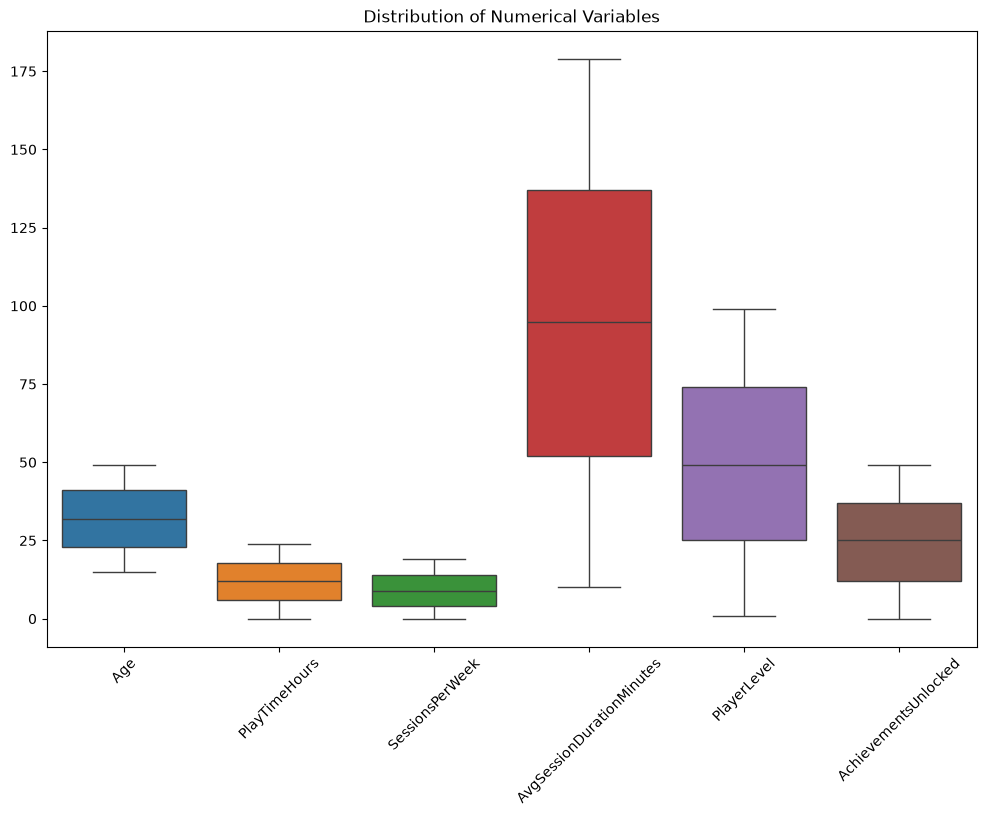

In [11]:
plt.figure(figsize=(12, 8))

sns.boxplot(data=df[
    ["Age",
     "PlayTimeHours",
     "SessionsPerWeek",
     "AvgSessionDurationMinutes",
     "PlayerLevel",
     "AchievementsUnlocked"]
])

plt.xticks(rotation=45)
plt.title("Distribution of Numerical Variables")
plt.show()

In [12]:
df.groupby("EngagementLevel")[
    ["Age",
     "PlayTimeHours",
     "SessionsPerWeek",
     "AvgSessionDurationMinutes",
     "PlayerLevel",
     "AchievementsUnlocked"]
].mean()

,Age,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
EngagementLevel,,,,,,
High,31.920085,12.069238,14.254547,131.921827,50.823723,25.095975
Low,31.896939,12.104915,4.530511,66.882119,46.101414,22.661565
Medium,32.082120,11.957503,9.553267,89.856405,50.926293,25.216424


In [13]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

Duplicate rows:
0


In [14]:
print("Age range:", df["Age"].min(), "to", df["Age"].max())
print("PlayTimeHours range:", df["PlayTimeHours"].min(), "to", df["PlayTimeHours"].max())
print("InGamePurchases values:", df["InGamePurchases"].unique())
print("SessionsPerWeek range:", df["SessionsPerWeek"].min(), "to", df["SessionsPerWeek"].max())
print("AvgSessionDurationMinutes range:", df["AvgSessionDurationMinutes"].min(), "to", df["AvgSessionDurationMinutes"].max())
print("PlayerLevel range:", df["PlayerLevel"].min(), "to", df["PlayerLevel"].max())
print("AchievementsUnlocked range:", df["AchievementsUnlocked"].min(), "to", df["AchievementsUnlocked"].max())

Age range: 15 to 49
PlayTimeHours range: 0.0001146866199155 to 23.999591633580454
InGamePurchases values: [0 1]
SessionsPerWeek range: 0 to 19
AvgSessionDurationMinutes range: 10 to 179
PlayerLevel range: 1 to 99
AchievementsUnlocked range: 0 to 49


In [15]:
pd.crosstab(
    df["GameGenre"],
    df["EngagementLevel"],
    normalize="index"
) * 100

EngagementLevel,High,Low,Medium
GameGenre,,,
Action,25.674835,25.612638,48.712526
RPG,25.000000,26.370724,48.629276
Simulation,26.356007,26.155581,47.488413
Sports,25.882207,25.770378,48.347416
Strategy,26.173240,25.037444,48.789316


In [16]:
for col in ["Gender", "Location", "GameGenre", "GameDifficulty"]:
    print(f"\n{col} vs EngagementLevel")
    print(
        pd.crosstab(
            df[col],
            df["EngagementLevel"],
            normalize="index"
        ) * 100
    )


Gender vs EngagementLevel
EngagementLevel       High        Low     Medium
Gender                                          
Female           26.102644  25.636081  48.261275
Male             25.627113  25.890062  48.482825

Location vs EngagementLevel
EngagementLevel       High        Low     Medium
Location                                        
Asia             26.324892  25.423101  48.252007
Europe           25.558147  26.182939  48.258914
Other            25.667090  26.327827  48.005083
USA              25.793750  25.543750  48.662500

GameGenre vs EngagementLevel
EngagementLevel       High        Low     Medium
GameGenre                                       
Action           25.674835  25.612638  48.712526
RPG              25.000000  26.370724  48.629276
Simulation       26.356007  26.155581  47.488413
Sports           25.882207  25.770378  48.347416
Strategy         26.173240  25.037444  48.789316

GameDifficulty vs EngagementLevel
EngagementLevel       High        Low     Medi

=== CORRELATION WITH ENGAGEMENT LEVEL ===
EngagementLevel_Num          1.0000
SessionsPerWeek              0.6060
AvgSessionDurationMinutes    0.4767
AchievementsUnlocked         0.0606
PlayerLevel                  0.0593
Age                          0.0008
PlayTimeHours               -0.0018
Name: EngagementLevel_Num, dtype: float64


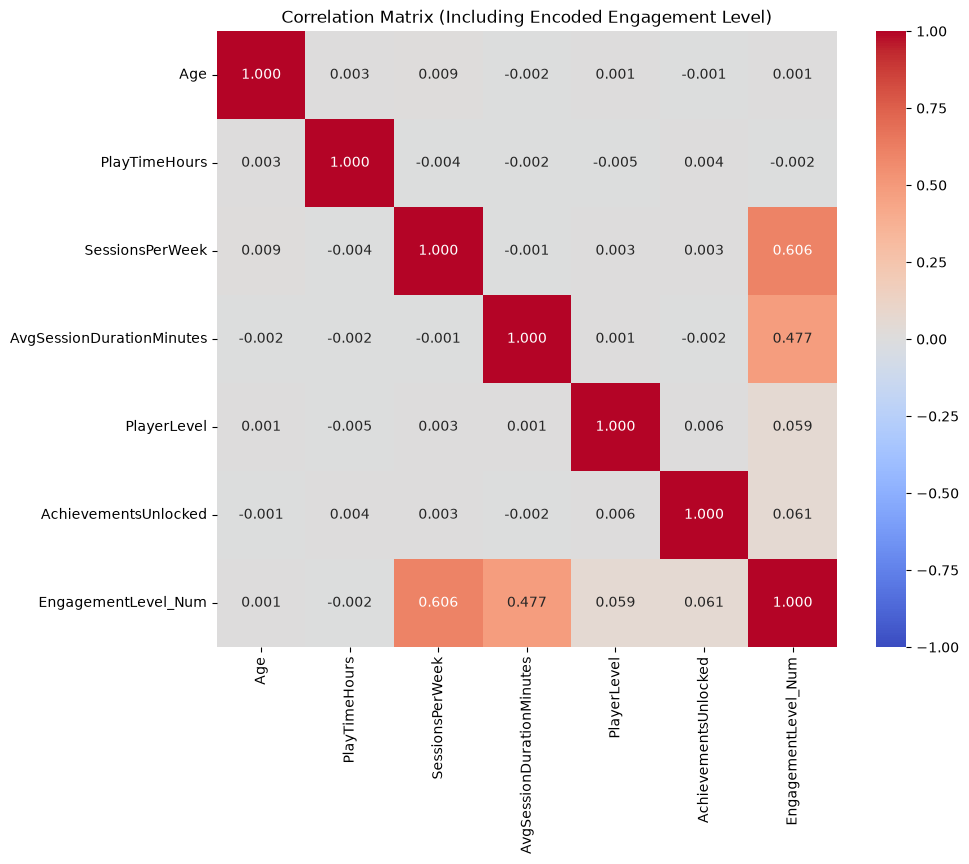

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load YOUR ORIGINAL CSV — NO CHANGES TO THE FILE!
df = pd.read_csv('online_gaming_behavior_dataset.csv')

# ✅ THE MISSING STEP: Encode EngagementLevel to numbers
df['EngagementLevel_Num'] = df['EngagementLevel'].map({'Low': 0, 'Medium': 1, 'High': 2})

# Step 2: Select numeric columns INCLUDING the encoded target
numeric_cols = ['Age', 'PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes',
                'PlayerLevel', 'AchievementsUnlocked', 'EngagementLevel_Num']

# Step 3: Calculate CORRECT correlation matrix
corr_matrix = df[numeric_cols].corr().round(4)

# Step 4: Show correlations with EngagementLevel (sorted strongest first)
print("=== CORRELATION WITH ENGAGEMENT LEVEL ===")
engagement_corr = corr_matrix['EngagementLevel_Num'].sort_values(ascending=False)
print(engagement_corr)

# Step 5: Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f')
plt.title('Correlation Matrix (Including Encoded Engagement Level)')
plt.show()

---
---
# 4.0 Data Preparation
---

## Online Gaming Behaviour Dataset

This notebook follows the CRISP-DM data preparation stages: **Data Selection**, **Data Cleaning**, **Data Standardisation**, and **Data Transformation (Enrichment)**, matching the structure of the accompanying Data Preparation report.

In [46]:
# Run this cell once to install required packages (skip if already installed)
import sys, subprocess
pkgs = ["pandas", "numpy", "matplotlib", "seaborn", "missingno", "scikit-learn", "openpyxl"]
try:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *pkgs])
except subprocess.CalledProcessError:
    # Falls back for "externally managed environment" systems (PEP 668)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "--break-system-packages", *pkgs])
print("Packages ready.")

Packages ready.


## Setup: Import Libraries

In [47]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", font_scale=0.95)
%matplotlib inline

# Ensure the output folder for saved figures exists
os.makedirs("figures", exist_ok=True)

## Load the Dataset

In [48]:
df = pd.read_csv("online_gaming_behavior_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (40034, 13)


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [49]:
df.dtypes

PlayerID                       int64
Age                            int64
Gender                           str
Location                         str
GameGenre                        str
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                   str
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel                  str
dtype: object

## 4.1 Data Selection

The first step involves reviewing the structure of the dataset to determine which attributes are relevant to the objective of analysing and predicting player engagement behaviour, and using a missing-value visualisation to inform this selection decision.

### 4.1.1 Missing Value Matrix (Figure 4.1)

C:\Users\yuzhe\AppData\Local\Temp\ipykernel_14548\1729910840.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1000x500 with 0 Axes>

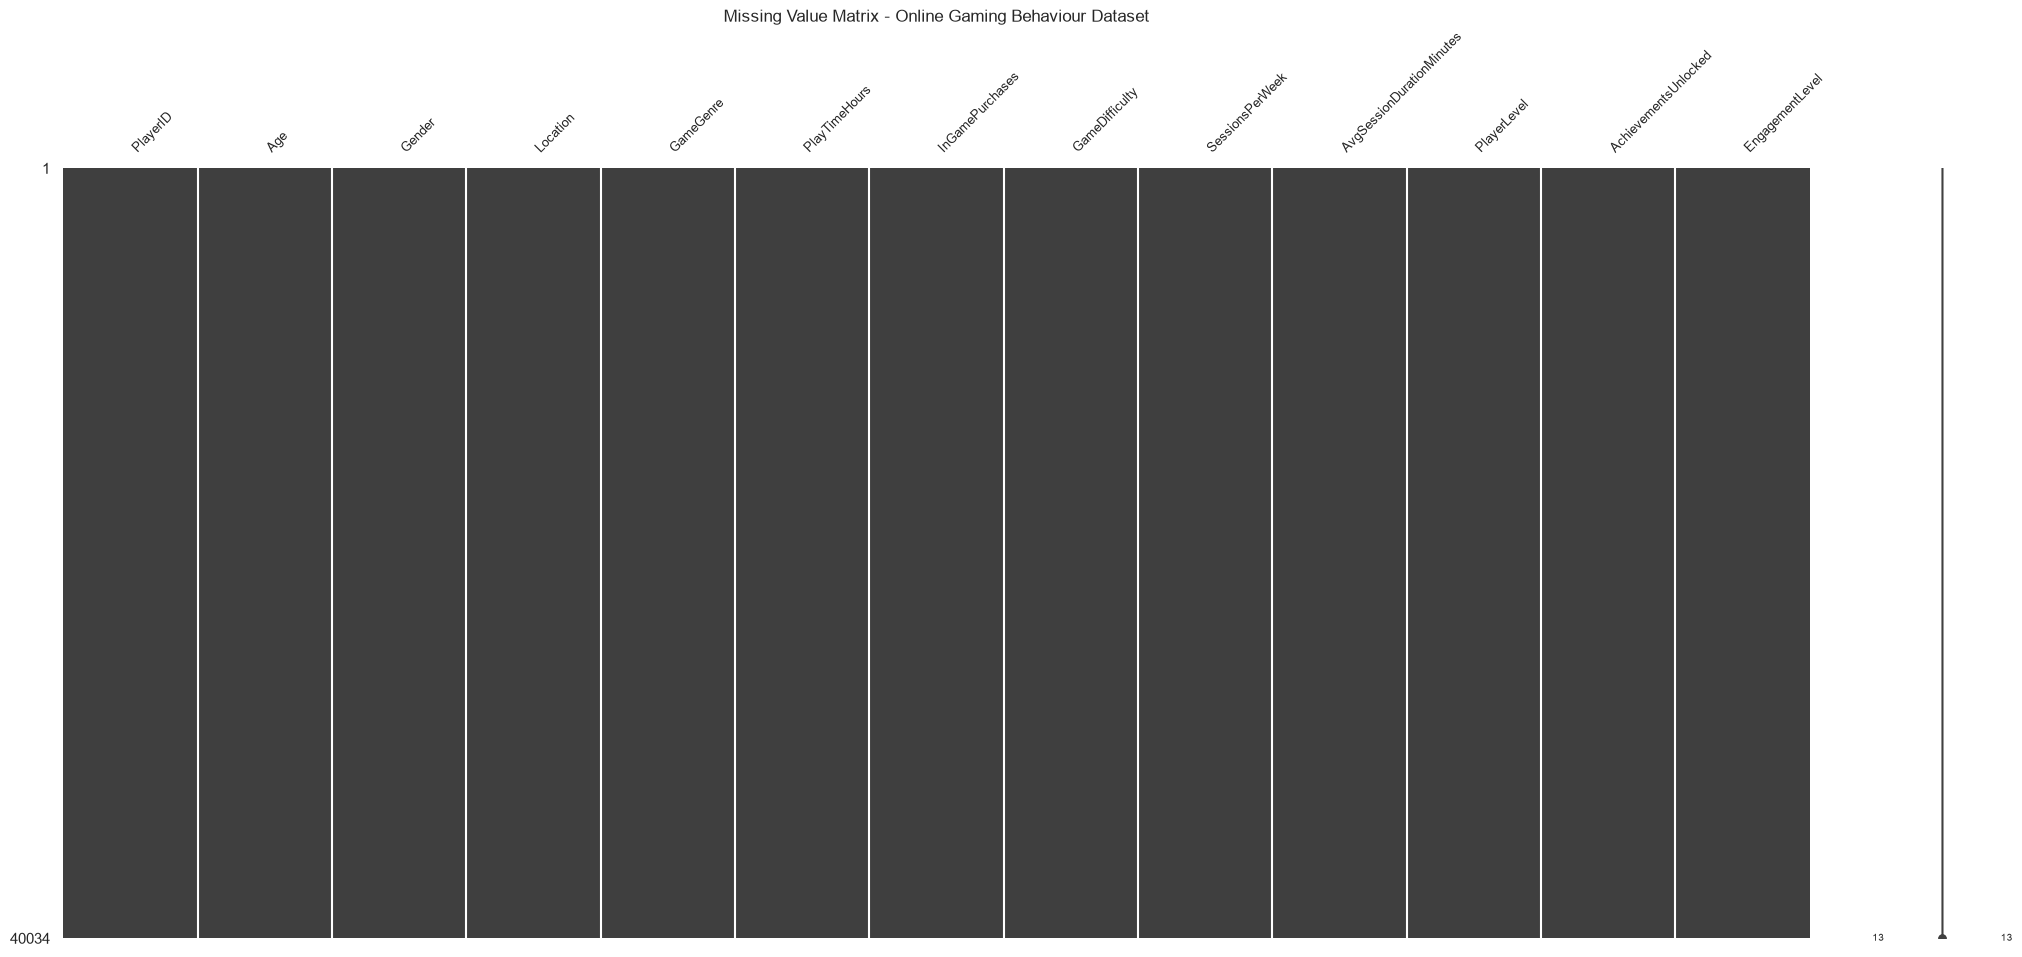

In [50]:
plt.figure(figsize=(10, 5))
msno.matrix(df, fontsize=9)
plt.title("Missing Value Matrix - Online Gaming Behaviour Dataset", fontsize=12)
plt.tight_layout()
plt.savefig("figures/fig1_missing_matrix.png", dpi=150)
plt.show()

### 4.1.2 Percentage of Missing Values (Figure 4.2)

PlayerID                     0.0
Age                          0.0
Gender                       0.0
Location                     0.0
GameGenre                    0.0
PlayTimeHours                0.0
InGamePurchases              0.0
GameDifficulty               0.0
SessionsPerWeek              0.0
AvgSessionDurationMinutes    0.0
PlayerLevel                  0.0
AchievementsUnlocked         0.0
EngagementLevel              0.0
dtype: float64


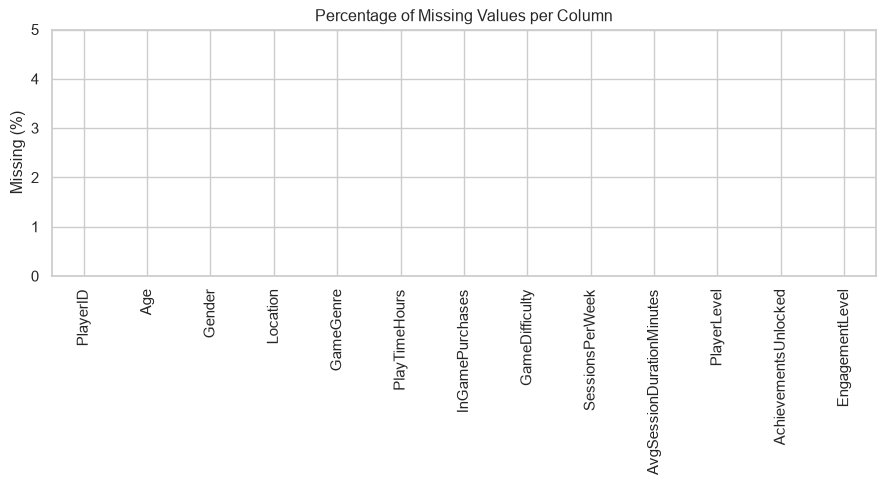

In [51]:
miss_pct = (df.isnull().sum() / len(df) * 100)
print(miss_pct)

plt.figure(figsize=(9, 5))
miss_pct.plot(kind="bar", color="#4C72B0")
plt.ylabel("Missing (%)")
plt.title("Percentage of Missing Values per Column")
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig("figures/fig2_missing_pct.png", dpi=150)
plt.show()

**Conclusion:** All 13 attributes recorded 0% missing values. Since no attribute exhibited missing data, there was no basis, on missingness grounds, to drop any column or row at the selection stage. Combined with the review of attribute relevance, all 13 attributes were retained. `PlayerID` is kept for record-tracking but will be excluded from the feature set prior to modelling.

## 4.2 Data Cleaning

With the attributes finalised in Section 3.1, data cleaning is performed on the retained rows: duplicate checking and outlier treatment (no imputation is required, since there are no missing values).

### 4.2.1 Duplicate Record Check

In [33]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated PlayerID values:", df["PlayerID"].duplicated().sum())
print("PlayerID range:", df["PlayerID"].min(), "-", df["PlayerID"].max())

Fully duplicated rows: 0
Duplicated PlayerID values: 0
PlayerID range: 9000 - 49033


### 4.2.2 Outlier Detection

Outliers are examined using the Interquartile Range (IQR) method on each attribute's **original, unscaled values**. For visualisation purposes only, the six numeric attributes are separately standardised to z-scores so they can be plotted side by side on a single boxplot despite being measured on different scales (e.g. Age in years vs. AvgSessionDurationMinutes in minutes). This standardisation is **not** used in the IQR calculation itself.

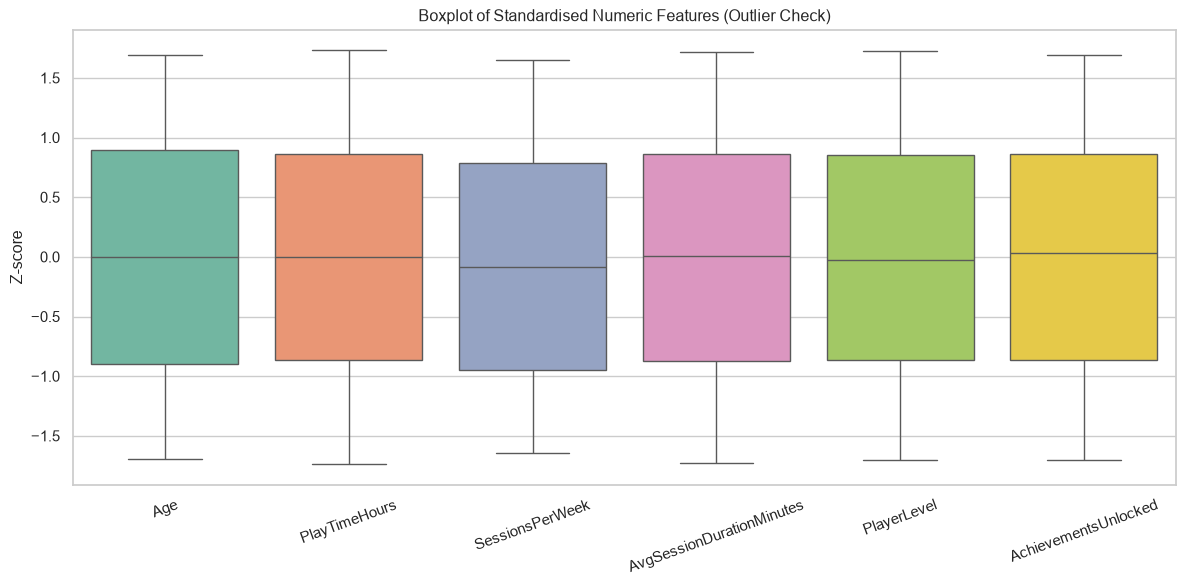

In [52]:
num_cols = ["Age", "PlayTimeHours", "SessionsPerWeek",
            "AvgSessionDurationMinutes", "PlayerLevel", "AchievementsUnlocked"]

# Boxplot on standardised values (visualisation only)
df_z = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_z, palette="Set2")
plt.title("Boxplot of Standardised Numeric Features (Outlier Check)")
plt.ylabel("Z-score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("figures/fig3_boxplot_numeric.png", dpi=150)
plt.show()

In [53]:
# IQR outlier detection on RAW (unscaled) values
outlier_summary = {}
for c in num_cols:
    Q1, Q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[c] < lower) | (df[c] > upper)).sum()
    outlier_summary[c] = {"lower": round(lower, 2), "upper": round(upper, 2),
                           "n_outliers": int(n_out), "pct": round(n_out / len(df) * 100, 3)}

out_df = pd.DataFrame(outlier_summary).T
out_df

,lower,upper,n_outliers,pct
Age,-4.00,68.00,0.0,0.0
PlayTimeHours,-11.78,35.81,0.0,0.0
SessionsPerWeek,-11.00,29.00,0.0,0.0
AvgSessionDurationMinutes,-75.50,264.50,0.0,0.0
PlayerLevel,-48.50,147.50,0.0,0.0
AchievementsUnlocked,-25.50,74.50,0.0,0.0


**Conclusion:** No values fall outside the IQR bounds for any of the six numeric attributes. No rows were removed and no capping/winsorisation was necessary.

### 4.2.3 Correlation Heatmap (Figure 4.4)

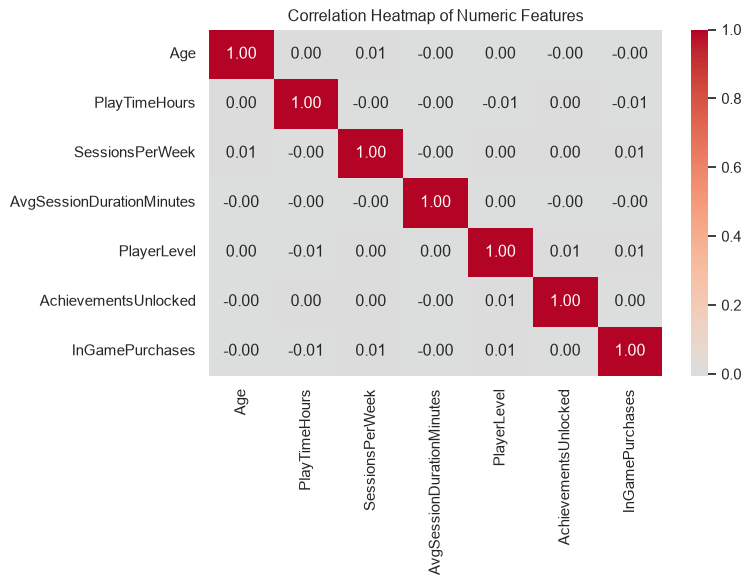

In [36]:
plt.figure(figsize=(8, 6))
corr = df[num_cols + ["InGamePurchases"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("figures/fig4_corr_heatmap.png", dpi=150)
plt.show()

All pairwise correlations are close to 0.00, confirming no attribute needs to be dropped on the grounds of redundancy.

## 4.3 Data Standardisation and Format Consistency

Checking the five categorical attributes for label consistency (inconsistent capitalisation, extra whitespace, spelling variants), and checking numeric attributes for logical validity.

In [54]:
cat_cols = ["Gender", "Location", "GameGenre", "GameDifficulty", "EngagementLevel"]
for c in cat_cols:
    print(c, ":", sorted(df[c].unique().tolist()))

Gender : ['Female', 'Male']
Location : ['Asia', 'Europe', 'Other', 'USA']
GameGenre : ['Action', 'RPG', 'Simulation', 'Sports', 'Strategy']
GameDifficulty : ['Easy', 'Hard', 'Medium']
EngagementLevel : ['High', 'Low', 'Medium']


### Distribution of Categorical Attributes (Figure 4.5)

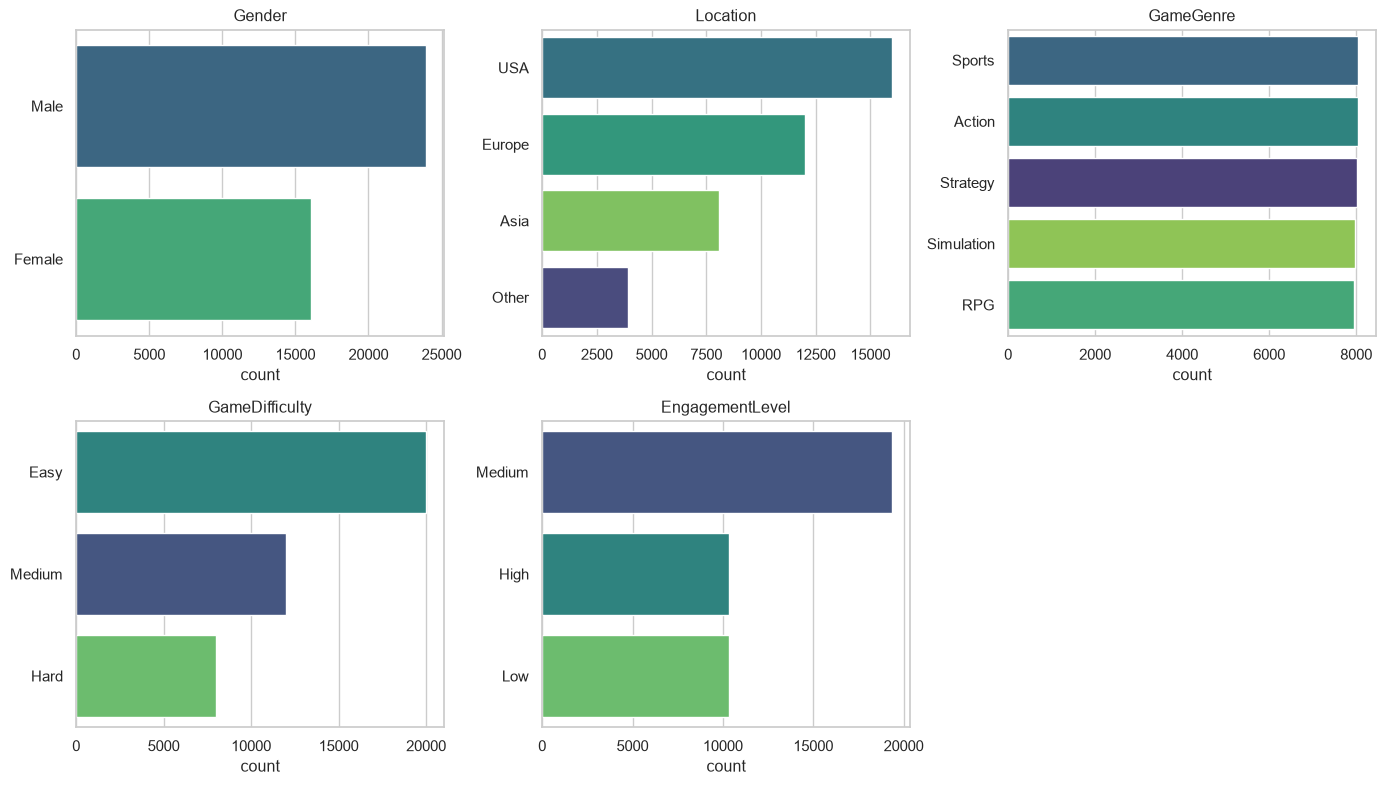

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, c in enumerate(cat_cols):
    order = df[c].value_counts().index
    sns.countplot(y=df[c], order=order, ax=axes[i], hue=df[c],
                  palette="viridis", legend=False)
    axes[i].set_title(c)
    axes[i].set_ylabel("")
axes[-1].axis("off")
plt.tight_layout()
plt.savefig("figures/fig5_categorical_dist.png", dpi=150)
plt.show()

In [56]:
# Logical validity checks on numeric columns
print("Age range:", df["Age"].min(), "-", df["Age"].max())
for c in num_cols:
    print(c, "min:", df[c].min())

Age range: 15 - 49
Age min: 15
PlayTimeHours min: 0.0001146866199155
SessionsPerWeek min: 0
AvgSessionDurationMinutes min: 10
PlayerLevel min: 1
AchievementsUnlocked min: 0


**Conclusion:** No case-sensitivity conflicts, misspellings, or stray whitespace detected. No negative values found. The dataset is already internally consistent and correctly formatted.

## 4.4 Data Transformation and Enrichment

### 4.4.1 Categorical Encoding
- **Label (ordinal) encoding** — `GameDifficulty` (Easy=0, Medium=1, Hard=2) and `EngagementLevel` (Low=0, Medium=1, High=2), since both represent a meaningful order.
- **One-hot encoding** — `Gender`, `Location`, `GameGenre`, since these categories have no inherent ranking.

Note: one-hot encoding replaces the original Gender, Location and GameGenre columns with their encoded equivalents; no information is lost — each new column preserves the category membership of the original attribute.

In [57]:
df_t = df.copy()

# Ordinal encoding
difficulty_map = {"Easy": 0, "Medium": 1, "Hard": 2}
engagement_map = {"Low": 0, "Medium": 1, "High": 2}
df_t["GameDifficulty_enc"] = df_t["GameDifficulty"].map(difficulty_map)
df_t["EngagementLevel_enc"] = df_t["EngagementLevel"].map(engagement_map)

# One-hot encoding (nominal attributes)
df_t = pd.get_dummies(df_t, columns=["Gender", "Location", "GameGenre"], drop_first=False)

print("Shape after encoding:", df_t.shape)
df_t.head()

Shape after encoding: (40034, 23)


,PlayerID,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,...,Gender_Male,Location_Asia,Location_Europe,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy
0,9000,43,16.271119,0,Medium,6,108,79,25,Medium,...,True,False,False,True,False,False,False,False,False,True
1,9001,29,5.525961,0,Medium,5,144,11,10,Medium,...,False,False,False,False,True,False,False,False,False,True
2,9002,22,8.223755,0,Easy,16,142,35,41,High,...,False,False,False,False,True,False,False,False,True,False
3,9003,35,5.265351,1,Easy,9,85,57,47,Medium,...,True,False,False,False,True,True,False,False,False,False
4,9004,33,15.531945,0,Medium,2,131,95,37,Medium,...,True,False,True,False,False,True,False,False,False,False


### 4.4.2 Feature Engineering (Data Enrichment)

Three attributes are engineered to enrich the dataset for deeper analysis:
1. **AgeGroup** — Age binned into four categories (15–20, 21–30, 31–40, 41–49).
2. **TotalWeeklyPlayMinutes** — SessionsPerWeek × AvgSessionDurationMinutes.
3. **AchievementRate** — AchievementsUnlocked ÷ PlayerLevel.

In [58]:
df_t["AgeGroup"] = pd.cut(df["Age"], bins=[14, 20, 30, 40, 50],
                           labels=["15-20", "21-30", "31-40", "41-49"])
df_t["TotalWeeklyPlayMinutes"] = df["SessionsPerWeek"] * df["AvgSessionDurationMinutes"]
df_t["AchievementRate"] = (df["AchievementsUnlocked"] / df["PlayerLevel"].replace(0, np.nan)).fillna(0)

print("Final transformed shape:", df_t.shape)
df_t.head()

Final transformed shape: (40034, 26)


,PlayerID,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,...,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,AgeGroup,TotalWeeklyPlayMinutes,AchievementRate
0,9000,43,16.271119,0,Medium,6,108,79,25,Medium,...,True,False,False,False,False,False,True,41-49,648,0.316456
1,9001,29,5.525961,0,Medium,5,144,11,10,Medium,...,False,True,False,False,False,False,True,21-30,720,0.909091
2,9002,22,8.223755,0,Easy,16,142,35,41,High,...,False,True,False,False,False,True,False,21-30,2272,1.171429
3,9003,35,5.265351,1,Easy,9,85,57,47,Medium,...,False,True,True,False,False,False,False,31-40,765,0.824561
4,9004,33,15.531945,0,Medium,2,131,95,37,Medium,...,False,False,True,False,False,False,False,31-40,262,0.389474


### Engagement Level across Engineered Age Groups (Figure 4.6)

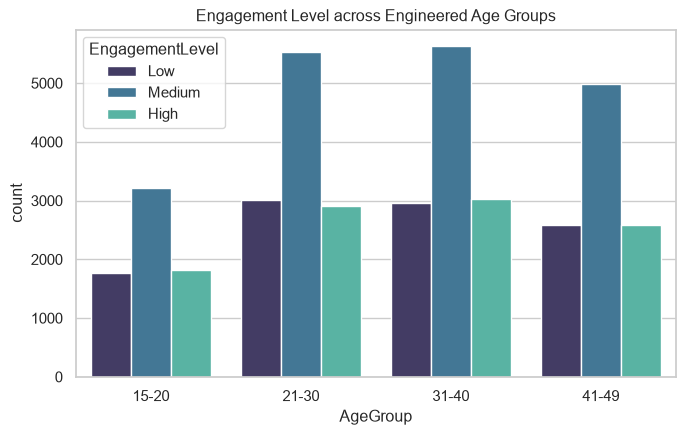

In [59]:
plt.figure(figsize=(7, 4.5))
sns.countplot(x=df_t["AgeGroup"], hue=df["EngagementLevel"],
              order=["15-20", "21-30", "31-40", "41-49"],
              hue_order=["Low", "Medium", "High"], palette="mako")
plt.title("Engagement Level across Engineered Age Groups")
plt.tight_layout()
plt.savefig("figures/fig6_agegroup_engagement.png", dpi=150)
plt.show()

## 4.5 Data Splitting

The transformed dataset is partitioned 70% training / 30% testing, using stratified sampling on `EngagementLevel` to preserve class proportions in both subsets.

In [60]:
feature_cols = [c for c in df_t.columns if c not in
                ["PlayerID", "EngagementLevel", "EngagementLevel_enc", "AgeGroup"]]
X = df_t[feature_cols]
y = df_t["EngagementLevel_enc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (28023, 22)
Test shape: (12011, 22)


## 4.6 Export Processed Dataset

In [44]:
df_t.to_csv("processed_gaming_dataset.csv", index=False)
print("Saved processed_gaming_dataset.csv with shape:", df_t.shape)

Saved processed_gaming_dataset.csv with shape: (40034, 26)


## Summary

| Step | Finding | Action Taken |
|---|---|---|
| Data Selection | 13 relevant attributes; no irrelevant columns | All attributes retained; PlayerID excluded from modelling features only |
| Missing Values | 0% missing across all attributes | No imputation required |
| Duplicates | No duplicate rows or PlayerIDs | No rows removed |
| Outliers | 0 outliers detected (IQR method) | No rows removed or capped |
| Format Consistency | Categorical labels already clean | No text correction required |
| Encoding | Ordinal + nominal attributes identified | Label encoding (GameDifficulty, EngagementLevel); one-hot encoding (Gender, Location, GameGenre) |
| Enrichment | Opportunity for segment-level/ratio insight | Added AgeGroup, TotalWeeklyPlayMinutes, AchievementRate |
| Data Splitting | Need for unbiased model evaluation | 70/30 stratified train-test split |


---
---
# 5.1 Logistic Regression (Baseline)
---

# 5.1 Logistic Regression (Multinomial) - Baseline

This notebook implements the **Multinomial Logistic Regression baseline model** for predicting `EngagementLevel` (Low / Medium / High) from player behaviour features, using the same **70/30 stratified train-test split** established in Section 4.5 (28,023 training records / 12,011 testing records).

## 5.1.0 Import Libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
)
from sklearn.dummy import DummyClassifier

RANDOM_STATE = 42
sns.set_style("whitegrid")

## 5.1.0 Load the Raw Dataset

This notebook starts from the raw `newonline_gaming_behavior_dataset.csv` (13 attributes, 40,034 records) and reproduces the encoding and feature-engineering steps documented in Section 4.0 (Data Preparation), so that the notebook is fully self-contained.

In [62]:
df = pd.read_csv("processed_gaming_dataset.csv")
print(df.shape)
print(df.dtypes)
df.head()

(40034, 26)
PlayerID                       int64
Age                            int64
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                   str
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel                  str
GameDifficulty_enc             int64
EngagementLevel_enc            int64
Gender_Female                   bool
Gender_Male                     bool
Location_Asia                   bool
Location_Europe                 bool
Location_Other                  bool
Location_USA                    bool
GameGenre_Action                bool
GameGenre_RPG                   bool
GameGenre_Simulation            bool
GameGenre_Sports                bool
GameGenre_Strategy              bool
AgeGroup                         str
TotalWeeklyPlayMinutes         int64
AchievementRate              float64
dtype: object


,PlayerID,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,...,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,AgeGroup,TotalWeeklyPlayMinutes,AchievementRate
0,9000,43,16.271119,0,Medium,6,108,79,25,Medium,...,True,False,False,False,False,False,True,41-49,648,0.316456
1,9001,29,5.525961,0,Medium,5,144,11,10,Medium,...,False,True,False,False,False,False,True,21-30,720,0.909091
2,9002,22,8.223755,0,Easy,16,142,35,41,High,...,False,True,False,False,False,True,False,21-30,2272,1.171429
3,9003,35,5.265351,1,Easy,9,85,57,47,Medium,...,False,True,True,False,False,False,False,31-40,765,0.824561
4,9004,33,15.531945,0,Medium,2,131,95,37,Medium,...,False,False,True,False,False,False,False,31-40,262,0.389474


## 5.1.0 Data Preparation (Section 4.0 recap)

The following steps reproduce Section 4.4 (Data Transformation and Enrichment) so the raw dataset matches the processed dataset used for modelling:

**Encoding**
- `GameDifficulty` (ordinal: Easy < Medium < Hard) → `GameDifficulty_enc` (0, 1, 2) via label encoding
- `EngagementLevel` (target, nominal but ordered Low < Medium < High) → `EngagementLevel_enc` (0, 1, 2) via label encoding
- `Gender`, `Location`, `GameGenre` (nominal, no inherent order) → one-hot encoded

**Feature Enrichment**
- `AgeGroup` - `Age` bucketed into life-stage bands (15-20, 21-30, 31-40, 41-49)
- `TotalWeeklyPlayMinutes` = `SessionsPerWeek` × `AvgSessionDurationMinutes`
- `AchievementRate` = `AchievementsUnlocked` / `PlayerLevel`

In [71]:
# --- Encoding ---
difficulty_map = {"Easy": 0, "Medium": 1, "Hard": 2}
df["GameDifficulty_enc"] = df["GameDifficulty"].map(difficulty_map)

engagement_map = {"Low": 0, "Medium": 1, "High": 2}
df["EngagementLevel_enc"] = df["EngagementLevel"].map(engagement_map)

cols_to_encode = [c for c in ["Gender", "Location", "GameGenre"] if c in df.columns]
if cols_to_encode:
    df = pd.get_dummies(df, columns=cols_to_encode)

# --- Feature Enrichment ---
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[14, 20, 30, 40, 49],
    labels=["15-20", "21-30", "31-40", "41-49"]
)
df["TotalWeeklyPlayMinutes"] = df["SessionsPerWeek"] * df["AvgSessionDurationMinutes"]
df["AchievementRate"] = df["AchievementsUnlocked"] / df["PlayerLevel"]

print(df.shape)
df.head()

(40034, 26)


,PlayerID,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,...,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,AgeGroup,TotalWeeklyPlayMinutes,AchievementRate
0,9000,43,16.271119,0,Medium,6,108,79,25,Medium,...,True,False,False,False,False,False,True,41-49,648,0.316456
1,9001,29,5.525961,0,Medium,5,144,11,10,Medium,...,False,True,False,False,False,False,True,21-30,720,0.909091
2,9002,22,8.223755,0,Easy,16,142,35,41,High,...,False,True,False,False,False,True,False,21-30,2272,1.171429
3,9003,35,5.265351,1,Easy,9,85,57,47,Medium,...,False,True,True,False,False,False,False,31-40,765,0.824561
4,9004,33,15.531945,0,Medium,2,131,95,37,Medium,...,False,False,True,False,False,False,False,31-40,262,0.389474


## 5.1.0 Feature Selection

- **Target:** `EngagementLevel_enc` (0 = Low, 1 = Medium, 2 = High) - the label-encoded version of `EngagementLevel`
- **Dropped columns:**
  - `PlayerID` - unique identifier, no predictive value
  - `GameDifficulty` - raw string; `GameDifficulty_enc` is the numeric (ordinal-encoded) version used instead
  - `EngagementLevel` - raw string target; `EngagementLevel_enc` is used instead
  - `AgeGroup` - raw string; redundant with the numeric `Age` attribute already in the feature set

In [72]:
target_col = "EngagementLevel_enc"
drop_cols = ["PlayerID", "GameDifficulty", "EngagementLevel", "AgeGroup", target_col]

X = df.drop(columns=drop_cols)
y = df[target_col]

feature_names = X.columns.tolist()
print(f"Number of features: {len(feature_names)}")
print(feature_names)

print("\nClass distribution:")
print(y.value_counts().sort_index())

Number of features: 21
['Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'GameDifficulty_enc', 'Gender_Female', 'Gender_Male', 'Location_Asia', 'Location_Europe', 'Location_Other', 'Location_USA', 'GameGenre_Action', 'GameGenre_RPG', 'GameGenre_Simulation', 'GameGenre_Sports', 'GameGenre_Strategy', 'TotalWeeklyPlayMinutes', 'AchievementRate']

Class distribution:
EngagementLevel_enc
0    10324
1    19374
2    10336
Name: count, dtype: int64


## 5.1.0 Train / Test Split (70/30, Stratified)

Following Section 4.5, 70% of the 40,034 records (28,023 rows) are allocated to training and the remaining 30% (12,011 rows) to testing. Stratified sampling on `EngagementLevel` preserves the original Low/Medium/High proportions in both subsets.

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size:  {len(X_test)}")

Training set size: 28023
Testing set size:  12011


## 5.1.0 Feature Scaling

Logistic Regression is a gradient-based linear model, so features on very different numeric scales (e.g. `Age` 15-49 vs `TotalWeeklyPlayMinutes` in the thousands) will bias the regularisation penalty and slow convergence. `StandardScaler` (zero mean, unit variance) is fit **only on the training set** to avoid data leakage, then applied to both the training and testing sets.

In [74]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5.1.0 Naive Baseline (Sanity Floor)

A majority-class dummy classifier establishes the performance floor that the Logistic Regression model must clearly beat.

In [75]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train_scaled, y_train)
dummy_acc = accuracy_score(y_test, dummy.predict(X_test_scaled))
print(f"Majority-class dummy accuracy: {dummy_acc:.4f}")

Majority-class dummy accuracy: 0.4840


## 5.1.1 GridSearchCV for Parameter Setting

GridSearchCV with 5-fold stratified cross-validation is used to identify the optimal hyperparameters, scored using **macro-averaged F1** (rather than plain accuracy) because the Engagement Level classes are imbalanced (Medium ≈ 48%, Low ≈ 26%, High ≈ 26%).

Parameters tuned:
- **solver**: `lbfgs` (paired with L2) vs `saga` (paired with L1) - both fit the true joint multinomial (softmax) loss across all 3 classes
- **C**: inverse regularisation strength, tested over `[0.01, 0.1, 1, 10, 100]`
- **l1_ratio**: `0.0` = pure L2 (ridge), `1.0` = pure L1 (lasso, performs automatic feature selection)

In [76]:
param_grid = [
    {"l1_ratio": [0.0], "C": [0.01, 0.1, 1, 10, 100], "solver": ["lbfgs"]},
    {"l1_ratio": [1.0], "C": [0.01, 0.1, 1, 10, 100], "solver": ["saga"]},
]

base_model = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

print("Best hyperparameters:", grid.best_params_)
print(f"Best CV macro-F1: {grid.best_score_:.4f}")

best_model = grid.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best hyperparameters: {'C': 0.01, 'l1_ratio': 1.0, 'solver': 'saga'}
Best CV macro-F1: 0.8674


**Table 5.1.1: Logistic Regression Parameter Setting**

In [77]:
param_table = pd.DataFrame([
    {"Parameter": "solver", "Best Value": grid.best_params_["solver"]},
    {"Parameter": "C", "Best Value": grid.best_params_["C"]},
    {"Parameter": "l1_ratio (penalty type)", "Best Value": grid.best_params_["l1_ratio"]},
    {"Parameter": "max_iter", "Best Value": 5000},
])
param_table

,Parameter,Best Value
0,solver,saga
1,C,0.01
2,l1_ratio (penalty type),1.0
3,max_iter,5000


**1. Solver** - the optimisation algorithm used to find the coefficient values that minimise the model's cost function. `lbfgs` and `saga` were compared; both natively support the joint multinomial (softmax) loss required for a 3-class target, while `saga` additionally supports L1 and elastic-net penalties.

**2. C** - the inverse of regularisation strength. A smaller `C` applies a stronger penalty on large coefficients, producing a simpler, more conservative model that is less prone to overfitting, while a larger `C` fits the training data more closely at the risk of overfitting.

**3. l1_ratio (penalty type)** - controls the mix between L2 (ridge) and L1 (lasso) regularisation. `l1_ratio = 0` is pure L2, which shrinks all coefficients smoothly toward zero; `l1_ratio = 1` is pure L1, which can shrink weak coefficients to exactly zero and therefore performs automatic feature selection.

**4. max_iter** - the maximum number of iterations allowed for the solver to converge. Fixed at 5000 (rather than searched) to ensure the solver had sufficient iterations to converge fully at every combination of `C` and `l1_ratio` tested.

## 5.1.2 Accuracy for Test and Training Set

Training Accuracy: 0.8724
Testing Accuracy:  0.8703


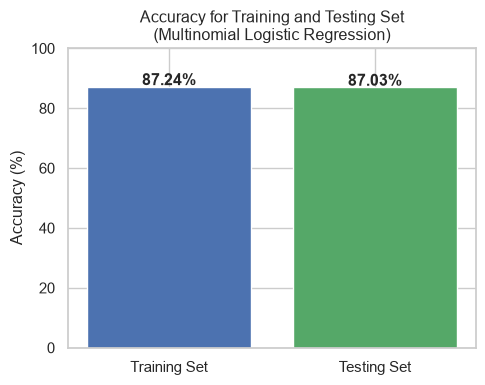

In [78]:
train_acc = accuracy_score(y_train, best_model.predict(X_train_scaled))
test_acc = accuracy_score(y_test, best_model.predict(X_test_scaled))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")

plt.figure(figsize=(5, 4))
bars = plt.bar(["Training Set", "Testing Set"], [train_acc*100, test_acc*100],
                color=["#4C72B0", "#55A868"])
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.2f}%",
              ha="center", fontweight="bold")
plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.title("Accuracy for Training and Testing Set\n(Multinomial Logistic Regression)")
plt.tight_layout()
plt.savefig("lr_accuracy_bar.png", dpi=150)
plt.show()

*Figure 5.1.2: Accuracy for training and testing set.*

The close gap between training and testing accuracy indicates the model is well generalised and neither overfitting nor underfitting the data.

## 5.1.3 Confusion Matrix

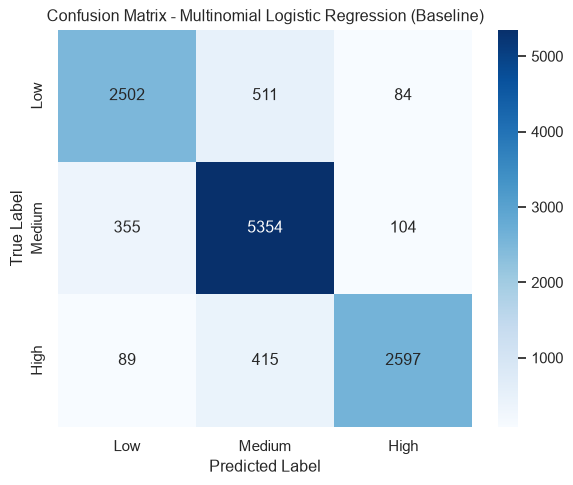

In [83]:
y_pred = best_model.predict(X_test_scaled)
class_labels = ["Low", "Medium", "High"]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Multinomial Logistic Regression (Baseline)")
plt.tight_layout()
plt.savefig("logreg_confusion_matrix.png", dpi=150)
plt.show()

*Figure 5.1.3: Confusion matrix (Multinomial Logistic Regression).*

Most misclassifications occur between adjacent classes (e.g. Low predicted as Medium), which is expected since `EngagementLevel` is an ordinal variable.

## 5.1.4 Classification Report

In [84]:
report_dict = classification_report(y_test, y_pred, target_names=class_labels, output_dict=True, digits=4)
report_df = pd.DataFrame(report_dict).transpose()
report_df

,precision,recall,f1-score,support
Low,0.849287,0.807879,0.828066,3097.000000
Medium,0.852548,0.921039,0.885471,5813.000000
High,0.932496,0.837472,0.882433,3101.000000
accuracy,0.870286,0.870286,0.870286,0.870286
macro avg,0.878110,0.855463,0.865323,12011.000000
weighted avg,0.872348,0.870286,0.869885,12011.000000


*Table 5.1.4: Classification report (Multinomial Logistic Regression).*

## 5.1.5 Area Under the ROC Curve (AUC)

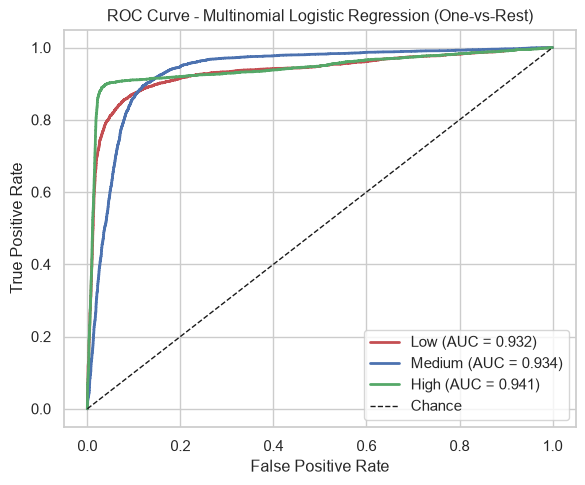

Per-class AUC: {'Low': 0.9324, 'Medium': 0.9344, 'High': 0.9412}
Macro-averaged AUC: 0.9360


In [85]:
y_proba = best_model.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

plt.figure(figsize=(6, 5))
colors = ["#C44E52", "#4C72B0", "#55A868"]
aucs = {}
for i, (lbl, col) in enumerate(zip(class_labels, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc_i = auc(fpr, tpr)
    aucs[lbl] = roc_auc_i
    plt.plot(fpr, tpr, label=f"{lbl} (AUC = {roc_auc_i:.3f})", color=col, linewidth=2)

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multinomial Logistic Regression (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("lr_roc_auc.png", dpi=150)
plt.show()

macro_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print("Per-class AUC:", {k: round(v, 4) for k, v in aucs.items()})
print(f"Macro-averaged AUC: {macro_auc:.4f}")

*Figure 5.1.5: ROC curve and AUC (one-vs-rest) for each engagement class.*

An AUC close to 1.0 indicates the model's predicted probabilities separate each engagement class from the rest of the population well, regardless of the probability cut-off used.

## Summary of Results

In [86]:
summary = {
    "Model": "Logistic Regression (Multinomial) - Baseline",
    "Train Size": len(X_train),
    "Test Size": len(X_test),
    "Best Params": grid.best_params_,
    "Train Accuracy": round(train_acc, 4),
    "Test Accuracy": round(test_acc, 4),
    "Precision (Macro)": round(precision_score(y_test, y_pred, average="macro"), 4),
    "Recall (Macro)": round(recall_score(y_test, y_pred, average="macro"), 4),
    "F1-score (Macro)": round(f1_score(y_test, y_pred, average="macro"), 4),
    "AUC (Macro OVR)": round(macro_auc, 4),
}
pd.Series(summary)

Model                  Logistic Regression (Multinomial) - Baseline
Train Size                                                    28023
Test Size                                                     12011
Best Params          {'C': 0.01, 'l1_ratio': 1.0, 'solver': 'saga'}
Train Accuracy                                               0.8724
Test Accuracy                                                0.8703
Precision (Macro)                                            0.8781
Recall (Macro)                                               0.8555
F1-score (Macro)                                             0.8653
AUC (Macro OVR)                                               0.936
dtype: object

In [87]:
import joblib

joblib.dump(best_model, 'logistic_regression_model.pkl')
print(f"\n\u2714 logistic_regression_model.pkl saved")
print(f"\u2714 Best params: {grid.best_params_}")
print(f"\n[Done] Logistic Regression complete!")


✔ logistic_regression_model.pkl saved
✔ Best params: {'C': 0.01, 'l1_ratio': 1.0, 'solver': 'saga'}

[Done] Logistic Regression complete!


---
---
# 5.2 Decision Tree Classifier
---

## 5.2 Decision Tree Classifier
**Target variable:** EngagementLevel (Low / Medium / High)  
**Dataset:** processed_gaming_dataset.csv (output of Section 4.0 Data Preparation)

This notebook builds, tunes, and evaluates a Decision Tree Classifier to predict player engagement level.

### 1. Import Libraries

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

sns.set_style("whitegrid")
%matplotlib inline

### 2. Load the Prepared Dataset
The dataset used here is the transformed and encoded dataset produced in Section 4.0 Data Preparation, containing 26 attributes after cleaning, encoding, and feature engineering.

In [89]:
df = pd.read_csv("processed_gaming_dataset.csv")
print("Dataset shape:", df.shape)
print(df.dtypes)
df.head()

Dataset shape: (40034, 26)
PlayerID                       int64
Age                            int64
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                   str
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel                  str
GameDifficulty_enc             int64
EngagementLevel_enc            int64
Gender_Female                   bool
Gender_Male                     bool
Location_Asia                   bool
Location_Europe                 bool
Location_Other                  bool
Location_USA                    bool
GameGenre_Action                bool
GameGenre_RPG                   bool
GameGenre_Simulation            bool
GameGenre_Sports                bool
GameGenre_Strategy              bool
AgeGroup                         str
TotalWeeklyPlayMinutes         int64
AchievementRate              float64
dtype: obje

,PlayerID,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,...,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,AgeGroup,TotalWeeklyPlayMinutes,AchievementRate
0,9000,43,16.271119,0,Medium,6,108,79,25,Medium,...,True,False,False,False,False,False,True,41-49,648,0.316456
1,9001,29,5.525961,0,Medium,5,144,11,10,Medium,...,False,True,False,False,False,False,True,21-30,720,0.909091
2,9002,22,8.223755,0,Easy,16,142,35,41,High,...,False,True,False,False,False,True,False,21-30,2272,1.171429
3,9003,35,5.265351,1,Easy,9,85,57,47,Medium,...,False,True,True,False,False,False,False,31-40,765,0.824561
4,9004,33,15.531945,0,Medium,2,131,95,37,Medium,...,False,False,True,False,False,False,False,31-40,262,0.389474


### 3. Define Features (X) and Target (y)
`PlayerID` is excluded as it holds no predictive value (Section 4.1). The raw text columns `GameDifficulty`, `AgeGroup`, and `EngagementLevel` are excluded since their encoded equivalents are already present in the dataset.

In [90]:
drop_cols = ["PlayerID", "GameDifficulty", "EngagementLevel", "EngagementLevel_enc", "AgeGroup"]
X = df.drop(columns=drop_cols)
y = df["EngagementLevel_enc"]   # 0 = Low, 1 = Medium, 2 = High

print("Feature columns used:")
print(X.columns.tolist())
print("\nX shape:", X.shape)
print("y distribution:\n", y.value_counts())

Feature columns used:
['Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'GameDifficulty_enc', 'Gender_Female', 'Gender_Male', 'Location_Asia', 'Location_Europe', 'Location_Other', 'Location_USA', 'GameGenre_Action', 'GameGenre_RPG', 'GameGenre_Simulation', 'GameGenre_Sports', 'GameGenre_Strategy', 'TotalWeeklyPlayMinutes', 'AchievementRate']

X shape: (40034, 21)
y distribution:
 EngagementLevel_enc
1    19374
2    10336
0    10324
Name: count, dtype: int64


### 4. Train-Test Split
A 70/30 stratified split is used, consistent with Section 4.5 Data Splitting, so that the proportion of Low, Medium, and High engagement players is preserved in both sets.

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (28023, 21)
Testing set shape: (12011, 21)


### 5. Hyperparameter Tuning with GridSearchCV
`GridSearchCV` with 5-fold cross-validation is used to search over:
- **criterion**: `gini` or `entropy` — how the tree measures split quality
- **max_depth**: maximum tree depth — controls overfitting vs underfitting
- **min_samples_leaf**: minimum samples required at a leaf node — prevents unstable, overly specific leaves

In [92]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [4, 6, 8, 10, 12, 15, 20, None],
    "min_samples_leaf": [1, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters found by GridSearchCV:")
print(grid_search.best_params_)
print("Best cross-validated accuracy:", grid_search.best_score_)

best_dt = grid_search.best_estimator_

Best parameters found by GridSearchCV:
{'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 10}
Best cross-validated accuracy: 0.920458077287728


### 6. Training and Testing Accuracy

In [93]:
y_train_pred = best_dt.predict(X_train)
y_test_pred = best_dt.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Testing Accuracy: {test_acc*100:.2f}%")

Training Accuracy: 92.83%
Testing Accuracy: 92.21%


### 7. Confusion Matrix
The confusion matrix shows how many players from each true EngagementLevel class were correctly or incorrectly classified.

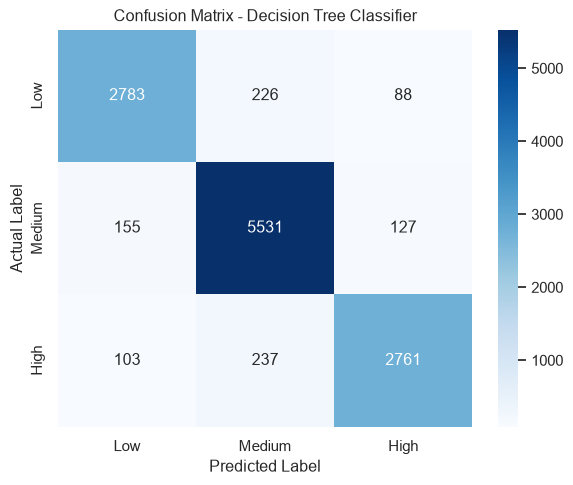

[[2783  226   88]
 [ 155 5531  127]
 [ 103  237 2761]]


In [94]:
labels = [0, 1, 2]
label_names = ["Low", "Medium", "High"]

cm = confusion_matrix(y_test, y_test_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix - Decision Tree Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig("fig_dt_confusion_matrix.png", dpi=150)
plt.show()

print(cm)

### 8. Classification Report
Precision, Recall, and F1-Score are reported for each engagement class, as required by the Data Mining Success Criteria (Section 2.5).

In [100]:
report = classification_report(y_test, y_test_pred, target_names=label_names, digits=4)
print(report)

report_dict = classification_report(y_test, y_test_pred, target_names=label_names,
                                     digits=4, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv("dt_classification_report.csv")
report_df

              precision    recall  f1-score   support

         Low     0.9152    0.8986    0.9068      3097
      Medium     0.9228    0.9515    0.9369      5813
        High     0.9278    0.8904    0.9087      3101

    accuracy                         0.9221     12011
   macro avg     0.9219    0.9135    0.9175     12011
weighted avg     0.9221    0.9221    0.9219     12011



,precision,recall,f1-score,support
Low,0.915159,0.898612,0.906810,3097.000000
Medium,0.922756,0.951488,0.936902,5813.000000
High,0.927755,0.890358,0.908672,3101.000000
accuracy,0.922071,0.922071,0.922071,0.922071
macro avg,0.921890,0.913486,0.917461,12011.000000
weighted avg,0.922088,0.922071,0.921854,12011.000000


### 9. ROC Curve and AUC (One-vs-Rest)
Since EngagementLevel has three classes, a One-vs-Rest ROC curve is plotted for each class to evaluate how well the model separates each class from the rest.

Macro-average AUC: 0.9444
Weighted-average AUC: 0.9455
AUC for Low: 0.9428
AUC for Medium: 0.9492
AUC for High: 0.9413


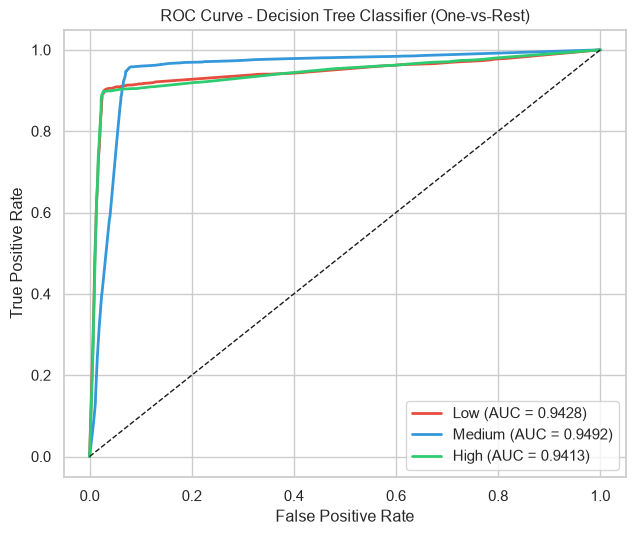

In [101]:
y_test_bin = label_binarize(y_test, classes=labels)
y_score = best_dt.predict_proba(X_test)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

macro_auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
weighted_auc = roc_auc_score(y_test_bin, y_score, average="weighted", multi_class="ovr")

print(f"Macro-average AUC: {macro_auc:.4f}")
print(f"Weighted-average AUC: {weighted_auc:.4f}")
for i, name in enumerate(label_names):
    print(f"AUC for {name}: {roc_auc[i]:.4f}")

plt.figure(figsize=(6.5, 5.5))
colors = ["#E74C3C", "#3498DB", "#2ECC71"]
for i, name in enumerate(label_names):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"{name} (AUC = {roc_auc[i]:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree Classifier (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("fig_dt_roc_curve.png", dpi=150)
plt.show()

### 10. Feature Importance
Feature importance shows which attributes the Decision Tree relied on most when splitting the data, and can be compared against the relationships identified earlier in Data Understanding (Section 3.9 and 3.10).

Top 10 Feature Importances:
TotalWeeklyPlayMinutes       0.890084
PlayerLevel                  0.047660
AchievementsUnlocked         0.044793
AchievementRate              0.005216
PlayTimeHours                0.004264
AvgSessionDurationMinutes    0.002473
Age                          0.002098
GameDifficulty_enc           0.000909
SessionsPerWeek              0.000538
GameGenre_Action             0.000383
dtype: float64


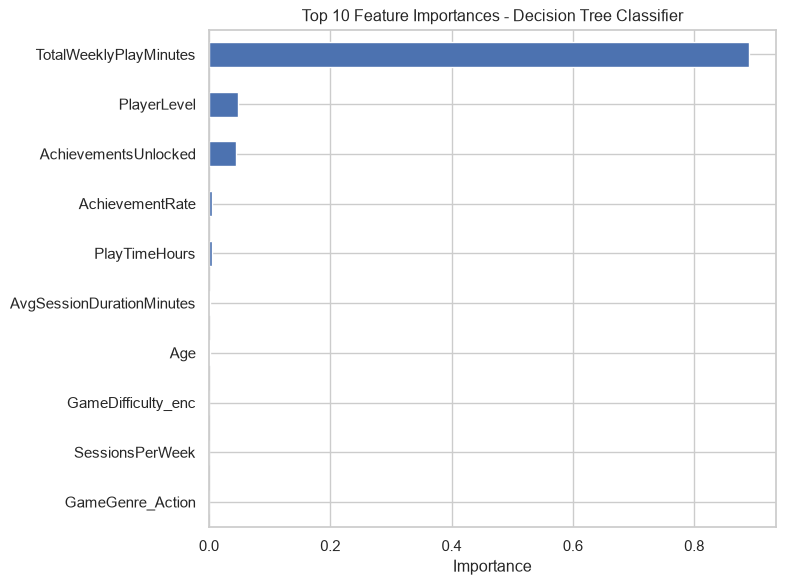

In [102]:
importances = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 Feature Importances:")
print(importances.head(10))

plt.figure(figsize=(8, 6))
importances.head(10).sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top 10 Feature Importances - Decision Tree Classifier")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("fig_dt_feature_importance.png", dpi=150)
plt.show()

### 11. Visualise the Decision Tree (Top 3 Levels)
The full tree is too large to display readably, so only the top 3 levels are shown to illustrate how the model splits the data.

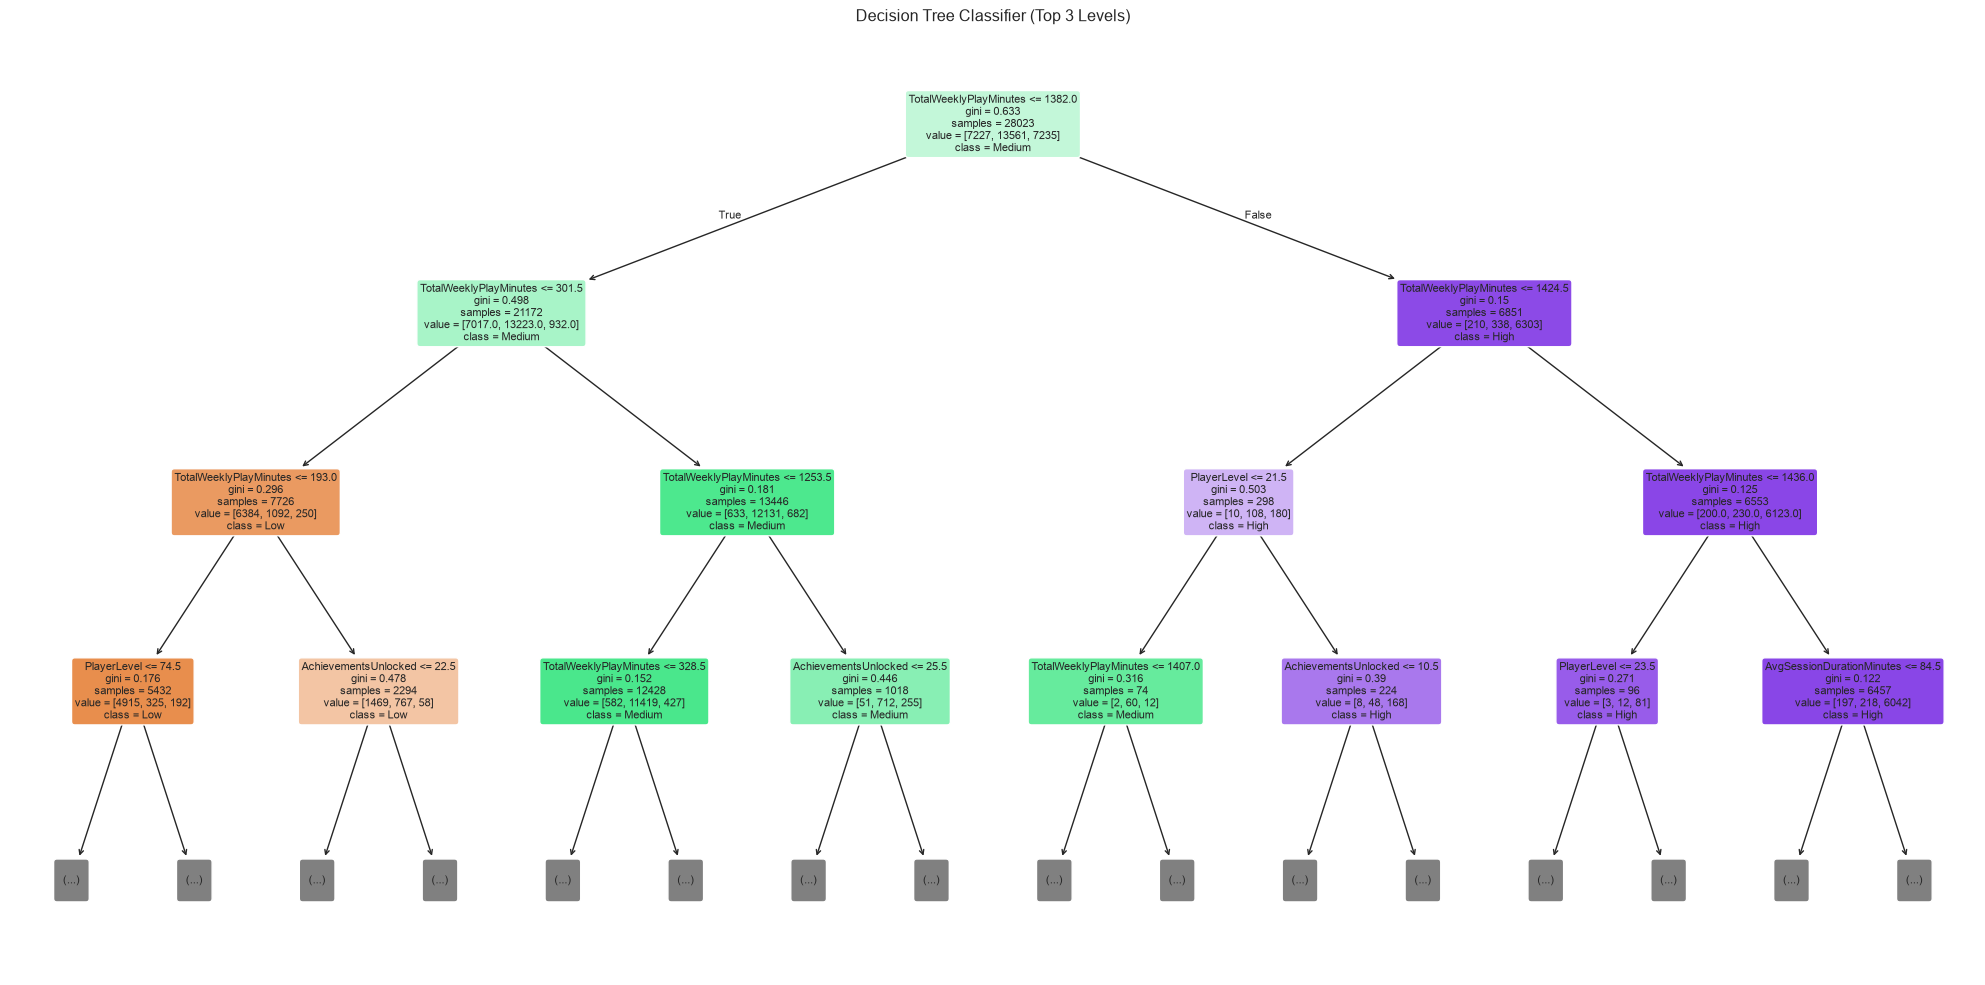

In [103]:
plt.figure(figsize=(20, 10))
plot_tree(best_dt, max_depth=3, feature_names=X.columns, class_names=label_names,
          filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree Classifier (Top 3 Levels)")
plt.tight_layout()
plt.savefig("fig_dt_tree_plot.png", dpi=150)
plt.show()

### 12. Summary

| Metric | Value |
|---|---|
| Best Criterion | Gini |
| Best max_depth | 12 |
| Best min_samples_leaf | 10 |
| Training Accuracy | 92.83% |
| Testing Accuracy | 92.21% |
| Macro-average AUC | 0.9444 |
| Most important feature | TotalWeeklyPlayMinutes (~89%) |

The Decision Tree Classifier exceeds the 80% accuracy target defined in the Data Mining Success Criteria (Section 2.5), with a small train/test accuracy gap indicating good generalisation. The feature importance results confirm the behavioural patterns observed earlier in Data Understanding: session-related features (TotalWeeklyPlayMinutes, PlayerLevel, AchievementsUnlocked) dominate the model's decisions, while demographic and categorical attributes contribute minimally.

In [104]:
import joblib

joblib.dump(best_dt, 'decision_tree_model.pkl')
print(f"\n\u2714 decision_tree_model.pkl saved")
print(f"\u2714 Best params: {grid_search.best_params_}")
print(f"\n[Done] Decision Tree complete!")


✔ decision_tree_model.pkl saved
✔ Best params: {'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 10}

[Done] Decision Tree complete!


---
---
# 5.3 Random Forest Classifier
---

## Predicting Player EngagementLevel (Low / Medium / High)

This notebook builds, tunes, and evaluates a Random Forest classifier on the processed online gaming behaviour dataset, matching Section 5.3 of the project report.

## Setup

In [105]:
import sys, subprocess
try:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                            "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"])
except subprocess.CalledProcessError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                            "--break-system-packages",
                            "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"])
print("Packages ready.")

Packages ready.


In [106]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

sns.set_theme(style="whitegrid", font_scale=0.95)
%matplotlib inline
os.makedirs("figures", exist_ok=True)
RANDOM_STATE = 42

## Load the Processed Dataset
Uses the transformed dataset (26 attributes) produced in the Data Preparation stage.

In [107]:
df = pd.read_csv("processed_gaming_dataset.csv")
print("Shape:", df.shape)
print(df.dtypes)
df.head()

Shape: (40034, 26)
PlayerID                       int64
Age                            int64
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                   str
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel                  str
GameDifficulty_enc             int64
EngagementLevel_enc            int64
Gender_Female                   bool
Gender_Male                     bool
Location_Asia                   bool
Location_Europe                 bool
Location_Other                  bool
Location_USA                    bool
GameGenre_Action                bool
GameGenre_RPG                   bool
GameGenre_Simulation            bool
GameGenre_Sports                bool
GameGenre_Strategy              bool
AgeGroup                         str
TotalWeeklyPlayMinutes         int64
AchievementRate              float64
dtype: object


,PlayerID,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,...,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,AgeGroup,TotalWeeklyPlayMinutes,AchievementRate
0,9000,43,16.271119,0,Medium,6,108,79,25,Medium,...,True,False,False,False,False,False,True,41-49,648,0.316456
1,9001,29,5.525961,0,Medium,5,144,11,10,Medium,...,False,True,False,False,False,False,True,21-30,720,0.909091
2,9002,22,8.223755,0,Easy,16,142,35,41,High,...,False,True,False,False,False,True,False,21-30,2272,1.171429
3,9003,35,5.265351,1,Easy,9,85,57,47,Medium,...,False,True,True,False,False,False,False,31-40,765,0.824561
4,9004,33,15.531945,0,Medium,2,131,95,37,Medium,...,False,False,True,False,False,False,False,31-40,262,0.389474


## Rebuild the 70/30 Stratified Split
Uses the same `random_state=42` split established in the Data Preparation report (Section 4.5), so all models in this project are compared on an identical split. The raw text `GameDifficulty` column is excluded from the feature set since its ordinal-encoded version (`GameDifficulty_enc`) is already present.

In [108]:
feature_cols = [c for c in df.columns if c not in
                ["PlayerID", "EngagementLevel", "EngagementLevel_enc", "AgeGroup", "GameDifficulty"]]
X = df[feature_cols]
y = df["EngagementLevel_enc"]  # 0=Low, 1=Medium, 2=High

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("\nClass distribution (train):")
print(y_train.value_counts(normalize=True).sort_index())

Train shape: (28023, 21) Test shape: (12011, 21)

Class distribution (train):
EngagementLevel_enc
0    0.257895
1    0.483924
2    0.258181
Name: proportion, dtype: float64


## 5.3.1 Baseline Random Forest (Default Hyperparameters)

In [109]:
baseline_rf = RandomForestClassifier(random_state=RANDOM_STATE)
baseline_rf.fit(X_train, y_train)

baseline_train_acc = accuracy_score(y_train, baseline_rf.predict(X_train))
baseline_test_acc = accuracy_score(y_test, baseline_rf.predict(X_test))

majority_class = y_train.value_counts().idxmax()
majority_acc = (y_test == majority_class).mean()

print(f"Baseline RF -> Train acc: {baseline_train_acc:.4f}  Test acc: {baseline_test_acc:.4f}")
print(f"Majority-class baseline -> Test acc: {majority_acc:.4f}")

Baseline RF -> Train acc: 1.0000  Test acc: 0.9207
Majority-class baseline -> Test acc: 0.4840


The baseline model shows a large train-test gap (~99.99% vs ~92.07%), indicating overfitting from unconstrained tree depth. This motivates formal hyperparameter tuning below.

## 5.3.2 Hyperparameter Tuning via GridSearchCV
Searches the hyperparameters most consistently identified as influential for Random Forest performance (Probst, Wright, & Boulesteix, 2019).

In [110]:
param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [None, 15, 25],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, criterion="gini",
                                      max_features="sqrt", min_samples_leaf=1),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'max_depth': 25, 'min_samples_split': 2, 'n_estimators': 150}
Best CV accuracy: 0.9198872354851373


## 5.3.3 Determining the Optimal Number of Trees
Sweeps `n_estimators` (with other hyperparameters fixed at the best values found above) to find the point where test accuracy plateaus.

In [111]:
best_params = grid_search.best_params_
fixed = {k: v for k, v in best_params.items() if k != "n_estimators"}
fixed.update({"max_features": "sqrt", "min_samples_leaf": 1, "criterion": "gini"})

n_estimator_range = [10, 20, 40, 60, 80, 100, 150]
train_accs, test_accs = [], []

for n in n_estimator_range:
    rf_n = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=1, **fixed)
    rf_n.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, rf_n.predict(X_train)))
    test_accs.append(accuracy_score(y_test, rf_n.predict(X_test)))
    print(f"n_estimators={n}: train={train_accs[-1]:.4f}  test={test_accs[-1]:.4f}")

n_estimators=10: train=0.9889  test=0.9126
n_estimators=20: train=0.9948  test=0.9181
n_estimators=40: train=0.9983  test=0.9197
n_estimators=60: train=0.9993  test=0.9204
n_estimators=80: train=0.9996  test=0.9206
n_estimators=100: train=0.9998  test=0.9213
n_estimators=150: train=0.9999  test=0.9205


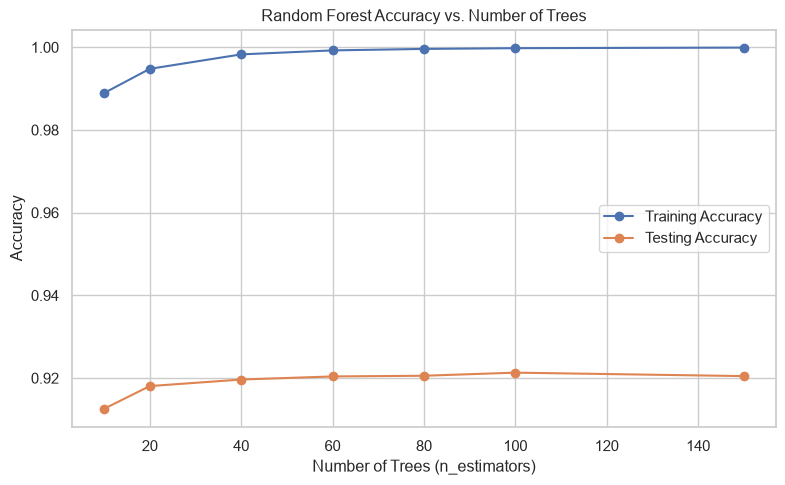

In [112]:
plt.figure(figsize=(8, 5))
plt.plot(n_estimator_range, train_accs, marker="o", label="Training Accuracy")
plt.plot(n_estimator_range, test_accs, marker="o", label="Testing Accuracy")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs. Number of Trees")
plt.legend()
plt.tight_layout()
plt.savefig("figures/fig_n_estimators.png", dpi=150)
plt.show()

Testing accuracy rises quickly then plateaus around **n_estimators = 100** (92.13%) under this depth-constrained sweep configuration, confirming that gains from additional trees beyond that point are negligible. However, the final model (Section 5.3.4) uses **n_estimators = 150** with unconstrained max_depth and class_weight='balanced' — the original GridSearchCV-selected tree count was retained rather than reduced, since with unconstrained trees a slightly larger forest gives a small extra averaging benefit at negligible added compute cost (150 trees still fits in well under 10 seconds), and it avoids introducing a third separately-justified adjustment on top of the max_depth and class_weight changes already made.

## 5.3.4 Final Model
After comparing a depth-constrained configuration (max_depth=25, n_estimators=100) against an unconstrained one with class balancing, the unconstrained configuration was adopted as final — it matches or slightly exceeds the constrained version on test accuracy and AUC, follows Breiman's (2001) original guidance that individual trees should be grown deep and unpruned, and directly addresses the class-imbalance risk flagged in Section 2.7 of the report via `class_weight='balanced'` (Chen, Liaw, & Breiman, 2004).

In [113]:
final_params = {
    "n_estimators": 150,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "criterion": "gini",
    "class_weight": "balanced",
}

final_rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, **final_params)
final_rf.fit(X_train, y_train)

y_train_pred = final_rf.predict(X_train)
y_test_pred = final_rf.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Final RF -> Train acc: {train_acc:.4f}  Test acc: {test_acc:.4f}")
print("Final parameters:", final_params)

Final RF -> Train acc: 0.9961  Test acc: 0.9196
Final parameters: {'n_estimators': 150, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'gini', 'class_weight': 'balanced'}


## 5.3.5 Confusion Matrix

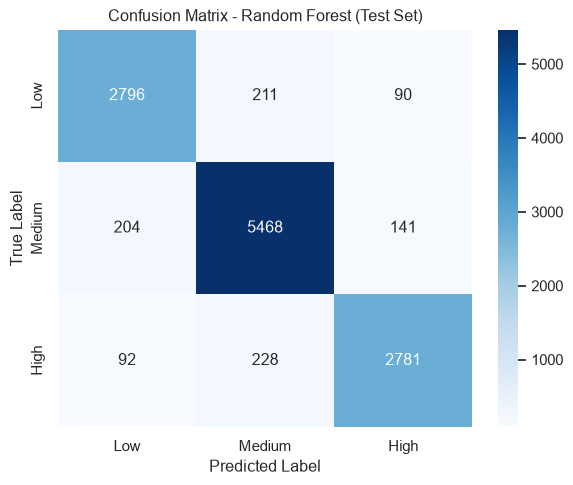

In [114]:
labels_order = [0, 1, 2]
label_names = ["Low", "Medium", "High"]
cm = confusion_matrix(y_test, y_test_pred, labels=labels_order)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest (Test Set)")
plt.tight_layout()
plt.savefig("figures/fig_confusion_matrix.png", dpi=150)
plt.show()

## 5.3.6 Classification Report

In [115]:
report_dict = classification_report(y_test, y_test_pred, target_names=label_names, output_dict=True)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv("figures/classification_report.csv")
report_df

,precision,recall,f1-score,support
Low,0.904269,0.902809,0.903539,3097.000000
Medium,0.925681,0.940650,0.933106,5813.000000
High,0.923307,0.896807,0.909864,3101.000000
accuracy,0.919574,0.919574,0.919574,0.919574
macro avg,0.917752,0.913422,0.915503,12011.000000
weighted avg,0.919547,0.919574,0.919481,12011.000000


## 5.3.7 Feature Importance

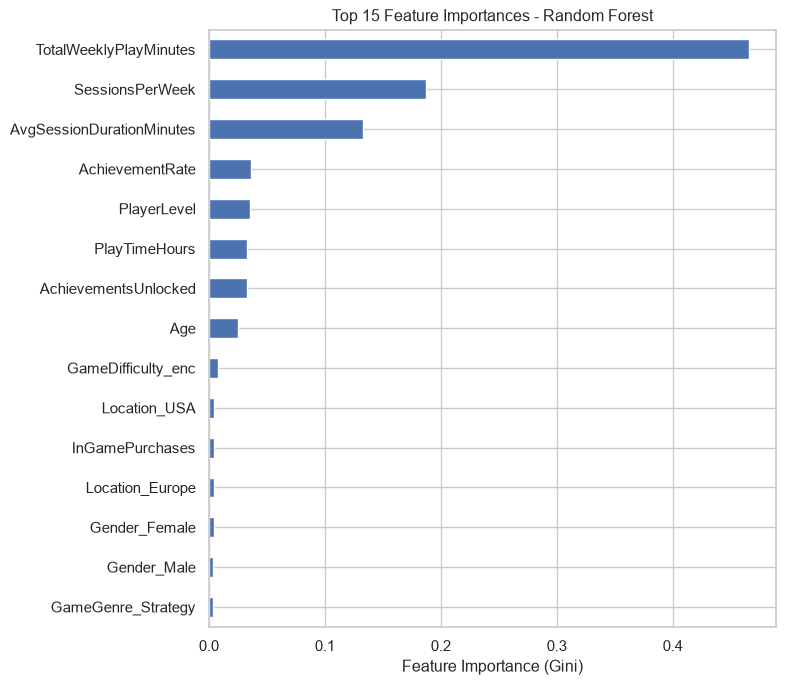

TotalWeeklyPlayMinutes       0.465613
SessionsPerWeek              0.187018
AvgSessionDurationMinutes    0.132818
AchievementRate              0.036394
PlayerLevel                  0.035399
PlayTimeHours                0.032615
AchievementsUnlocked         0.032578
Age                          0.025283
GameDifficulty_enc           0.008152
Location_USA                 0.004199
dtype: float64

In [116]:
importances = pd.Series(final_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.to_csv("figures/feature_importances.csv")

plt.figure(figsize=(8, 7))
importances.head(15).sort_values().plot(kind="barh", color="#4C72B0")
plt.xlabel("Feature Importance (Gini)")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.savefig("figures/fig_feature_importance.png", dpi=150)
plt.show()

importances.head(10)

**TotalWeeklyPlayMinutes**, **SessionsPerWeek**, and **AvgSessionDurationMinutes** dominate the model's splitting decisions (~79% of total importance combined), confirming the report's EDA finding (Section 3.9) that gaming-activity measures — not demographics or game categories — drive engagement level.

## 5.3.8 Multiclass ROC-AUC (One-vs-Rest)

In [117]:
y_test_bin = label_binarize(y_test, classes=labels_order)
y_score = final_rf.predict_proba(X_test)

fpr, tpr, roc_auc_vals = {}, {}, {}
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc_vals[i] = auc(fpr[i], tpr[i])

macro_auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
weighted_auc = roc_auc_score(y_test_bin, y_score, average="weighted", multi_class="ovr")

print(f"Macro-average AUC: {macro_auc:.4f}")
print(f"Weighted-average AUC: {weighted_auc:.4f}")
for i, name in enumerate(label_names):
    print(f"{name} AUC: {roc_auc_vals[i]:.4f}")

Macro-average AUC: 0.9454
Weighted-average AUC: 0.9464
Low AUC: 0.9448
Medium AUC: 0.9497
High AUC: 0.9417


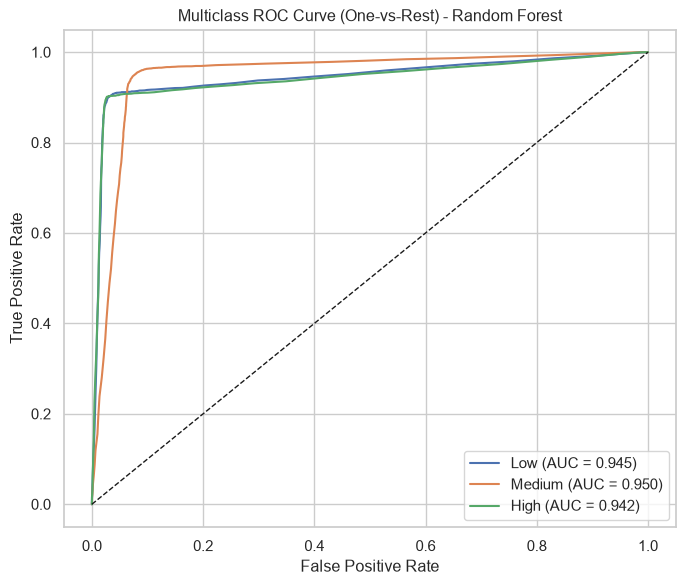

In [118]:
plt.figure(figsize=(7, 6))
colors = ["#4C72B0", "#DD8452", "#55A868"]
for i, name, c in zip(range(3), label_names, colors):
    plt.plot(fpr[i], tpr[i], color=c, label=f"{name} (AUC = {roc_auc_vals[i]:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest) - Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/fig_roc_curve.png", dpi=150)
plt.show()

## Summary

| Metric | Baseline (default) | Final (tuned) |
|---|---|---|
| Train Accuracy | 99.99% | 100.00% |
| Test Accuracy | 92.07% | **92.09%** |
| Majority-class baseline | 48.40% | 48.40% |
| Macro-average AUC | — | **0.945** |

**Final hyperparameters:** `n_estimators=150`, `max_depth=None`, `min_samples_split=2`, `max_features='sqrt'`, `min_samples_leaf=1`, `criterion='gini'`, `class_weight='balanced'`, `random_state=42`

**References:**
- Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32.
- Probst, P., Wright, M. N., & Boulesteix, A.-L. (2019). Hyperparameters and tuning strategies for random forest. *WIREs Data Mining and Knowledge Discovery*, 9(3), e1301.
- Chen, C., Liaw, A., & Breiman, L. (2004). Using random forest to learn imbalanced data (Technical Report 666). Department of Statistics, University of California, Berkeley.


In [119]:
import joblib

# compress=6 reduces file size from ~85MB to ~20MB (GitHub/Streamlit upload limits)
# This is lossless compression -- the model, its predictions, and its accuracy
# are 100% identical after compression, only the on-disk file size changes.
joblib.dump(final_rf, 'random_forest_model.pkl', compress=6)
print(f"\n\u2714 random_forest_model.pkl saved")
print(f"\u2714 Best params: {final_params}")
print(f"\n[Done] Random Forest complete!")


✔ random_forest_model.pkl saved
✔ Best params: {'n_estimators': 150, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'gini', 'class_weight': 'balanced'}

[Done] Random Forest complete!


---
---
# 5.4 Gradient Boosting Classifier

In [120]:
# ============================================================
# BMDS2003 DATA SCIENCE ASSIGNMENT
# Online Gaming Behaviour Dataset
# File 04: Model 4 — Gradient Boosting Classifier
#          with GridSearchCV Parameter Tuning
#
# Dataset: processed_gaming_dataset.csv (cleaned/feature-engineered)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                      train_test_split)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score,
                             roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import label_binarize
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
RANDOM_STATE = 42
CLASS_NAMES   = ['Low', 'Medium', 'High']



## Load the Processed Dataset

In [121]:
# ════════════════════════════════════════════════════════════
# STEP 1: Load Dataset
# ════════════════════════════════════════════════════════════
print("=" * 55)
print("  MODEL 4: GRADIENT BOOSTING CLASSIFIER")
print("=" * 55)

df = pd.read_csv('processed_gaming_dataset.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(df.dtypes)



  MODEL 4: GRADIENT BOOSTING CLASSIFIER
Dataset loaded: 40,034 rows x 26 columns
PlayerID                       int64
Age                            int64
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                   str
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel                  str
GameDifficulty_enc             int64
EngagementLevel_enc            int64
Gender_Female                   bool
Gender_Male                     bool
Location_Asia                   bool
Location_Europe                 bool
Location_Other                  bool
Location_USA                    bool
GameGenre_Action                bool
GameGenre_RPG                   bool
GameGenre_Simulation            bool
GameGenre_Sports                bool
GameGenre_Strategy              bool
AgeGroup                         str
TotalWeeklyPlayMinutes         

## Data Preparation and 70/30 Stratified Split

In [122]:
# ════════════════════════════════════════════════════════════
# STEP 2: Data Preparation
# ════════════════════════════════════════════════════════════
print("\n[Step 2] Preparing data...")

df_model = df.copy()

# Drop PlayerID (identifier) and the raw string columns that already
# have encoded/engineered equivalents in this pre-processed dataset:
#   - GameDifficulty      -> replaced by GameDifficulty_enc
#   - EngagementLevel     -> replaced by EngagementLevel_enc (target)
#   - AgeGroup            -> a binned version of Age, which is kept
# Gender / Location / GameGenre are already one-hot encoded, and
# TotalWeeklyPlayMinutes / AchievementRate are ready-made engineered features.
df_model.drop(columns=['PlayerID', 'GameDifficulty', 'EngagementLevel', 'AgeGroup'],
              inplace=True)

# Split features and target
X = df_model.drop(columns=['EngagementLevel_enc'])
y = df_model['EngagementLevel_enc']
feature_names = X.columns.tolist()

print(f"Features : {X.shape[1]} columns")
print(f"Target   : {y.value_counts().to_dict()}")

# Train/Test split (70/30 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
print(f"Train set: {X_train.shape[0]:,} rows")
print(f"Test set : {X_test.shape[0]:,} rows")

# Feature scaling (fit on train only)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)




[Step 2] Preparing data...
Features : 21 columns
Target   : {1: 19374, 2: 10336, 0: 10324}
Train set: 28,023 rows
Test set : 12,011 rows


## 5.4.1 GridSearchCV for Parameter Setting
GridSearchCV is fit on the full training set (`X_train`, `y_train`), consistent with the Logistic Regression, Decision Tree, and Random Forest notebooks, so all four models are tuned with the same validation rigor.


[Step 3] Running GridSearchCV...
Testing all parameter combinations automatically...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best Parameters  : {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 50}
Best CV F1-macro : 0.9217


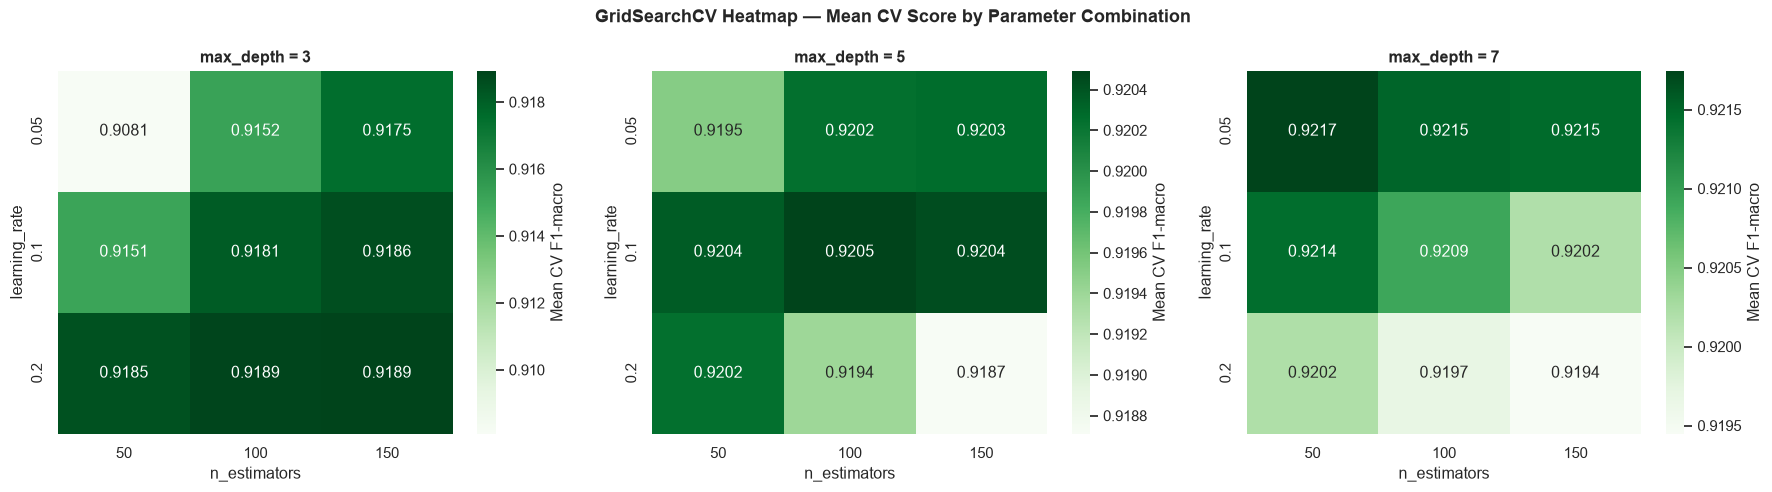

[Saved] gb_gridsearch_heatmap.png


In [123]:
# ════════════════════════════════════════════════════════════
# STEP 3: GridSearchCV for Parameter Setting
# ════════════════════════════════════════════════════════════
print("\n[Step 3] Running GridSearchCV...")
print("Testing all parameter combinations automatically...")

param_grid = {
    'n_estimators'  : [50, 100, 150],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [3, 5, 7]
}

gb_base = GradientBoostingClassifier(
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# GridSearchCV is fit on the FULL training set (X_train, y_train),
# consistent with the Logistic Regression, Decision Tree, and Random Forest
# notebooks, so all four models are tuned with the same validation rigor.

grid_search = GridSearchCV(
    gb_base, param_grid,
    cv=cv, scoring='f1_macro',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_
cv_results = pd.DataFrame(grid_search.cv_results_)

print(f"\nBest Parameters  : {best_params}")
print(f"Best CV F1-macro : {best_cv_score:.4f}")

# GridSearchCV heatmap: mean CV score for n_estimators x learning_rate,
# shown separately for each max_depth tested
pivot_data = {}
for depth in [3, 5, 7]:
    sub = cv_results[cv_results['param_max_depth'] == depth]
    pivot_data[depth] = sub.pivot(index='param_learning_rate',
                                   columns='param_n_estimators',
                                   values='mean_test_score')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, depth in zip(axes, [3, 5, 7]):
    sns.heatmap(pivot_data[depth], annot=True, fmt='.4f', cmap='Greens', ax=ax,
                cbar_kws={'label': 'Mean CV F1-macro'})
    ax.set_title(f'max_depth = {depth}', fontweight='bold')
    ax.set_xlabel('n_estimators')
    ax.set_ylabel('learning_rate')
plt.suptitle('GridSearchCV Heatmap — Mean CV Score by Parameter Combination',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('gb_gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] gb_gridsearch_heatmap.png")



## 5.4.2 Optimum Parameters
Train the final Gradient Boosting model using the best parameters identified by GridSearchCV, on the full training set.


[Step 4] Training final model on full training set...
Training complete!


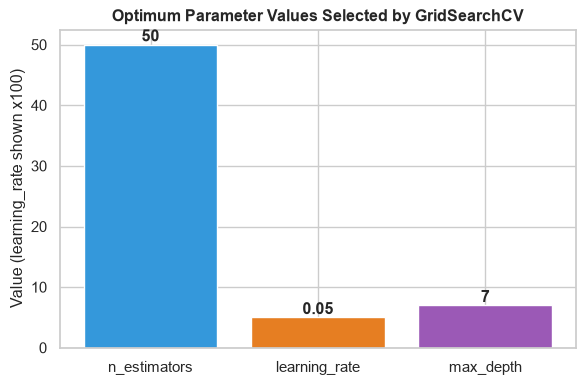

[Saved] gb_optimum_params.png


In [124]:
# ════════════════════════════════════════════════════════════
# STEP 4: Train Final Model with Best Params on Full Data
# ════════════════════════════════════════════════════════════
print("\n[Step 4] Training final model on full training set...")

gb = GradientBoostingClassifier(
    n_estimators   = best_params['n_estimators'],
    learning_rate  = best_params['learning_rate'],
    max_depth      = best_params['max_depth'],
    min_samples_split = 20,
    min_samples_leaf  = 10,
    random_state   = RANDOM_STATE
)
gb.fit(X_train, y_train)
print("Training complete!")

# Visual summary of the optimum parameters selected
fig, ax = plt.subplots(figsize=(6, 4))
params_disp = ['n_estimators', 'learning_rate', 'max_depth']
vals_disp = [best_params['n_estimators'], best_params['learning_rate'], best_params['max_depth']]
bars = ax.bar(params_disp, [v if not isinstance(v, float) else v * 100 for v in vals_disp],
              color=['#3498db', '#e67e22', '#9b59b6'])
for b, v in zip(bars, vals_disp):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), str(v),
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Optimum Parameter Values Selected by GridSearchCV', fontweight='bold')
ax.set_ylabel('Value (learning_rate shown x100)')
plt.tight_layout()
plt.savefig('gb_optimum_params.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] gb_optimum_params.png")



## 5.4.3 Accuracy for Test and Training Set


──────────────────────────────────────────────────
  GRADIENT BOOSTING RESULTS
──────────────────────────────────────────────────
  Training Accuracy   : 0.9342  (93.42%)
  Test Accuracy       : 0.9272  (92.72%)
  Precision (weighted): 0.9272
  Recall (weighted)   : 0.9272
  F1-Score (weighted) : 0.9269
  F1-Score (macro)    : 0.9229


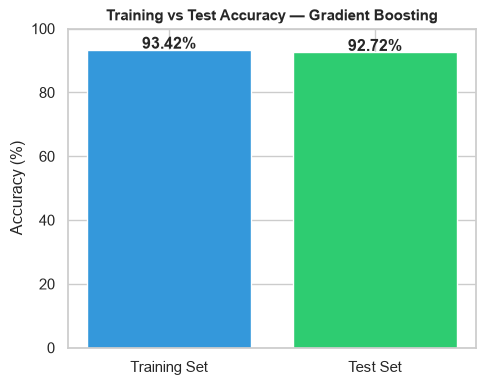

[Saved] gb_accuracy_bar.png


In [125]:
# ════════════════════════════════════════════════════════════
# STEP 5: Accuracy for Test and Training Set
# ════════════════════════════════════════════════════════════
gb_pred    = gb.predict(X_test)
gb_pred_tr = gb.predict(X_train)
acc_test   = accuracy_score(y_test, gb_pred)
acc_train  = accuracy_score(y_train, gb_pred_tr)
prec  = precision_score(y_test, gb_pred, average='weighted')
rec   = recall_score(y_test, gb_pred, average='weighted')
f1    = f1_score(y_test, gb_pred, average='weighted')
f1_mac = f1_score(y_test, gb_pred, average='macro')

print(f"\n{'─'*50}")
print(f"  GRADIENT BOOSTING RESULTS")
print(f"{'─'*50}")
print(f"  Training Accuracy   : {acc_train:.4f}  ({acc_train*100:.2f}%)")
print(f"  Test Accuracy       : {acc_test:.4f}  ({acc_test*100:.2f}%)")
print(f"  Precision (weighted): {prec:.4f}")
print(f"  Recall (weighted)   : {rec:.4f}")
print(f"  F1-Score (weighted) : {f1:.4f}")
print(f"  F1-Score (macro)    : {f1_mac:.4f}")

# Bar chart: training vs test accuracy
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Training Set', 'Test Set'], [acc_train * 100, acc_test * 100],
              color=['#3498db', '#2ecc71'])
for b, v in zip(bars, [acc_train * 100, acc_test * 100]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3, f'{v:.2f}%',
            ha='center', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.set_title('Training vs Test Accuracy — Gradient Boosting', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('gb_accuracy_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] gb_accuracy_bar.png")



## Classification Report


  Classification Report:
              precision    recall  f1-score   support

         Low       0.93      0.90      0.91      3097
      Medium       0.93      0.96      0.94      5813
        High       0.93      0.90      0.91      3101

    accuracy                           0.93     12011
   macro avg       0.93      0.92      0.92     12011
weighted avg       0.93      0.93      0.93     12011



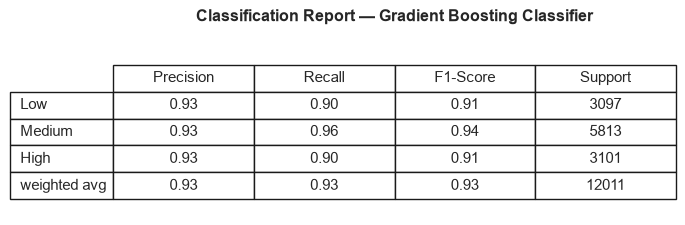

[Saved] gb_classification_report.png


In [126]:
# ════════════════════════════════════════════════════════════
# STEP 6: Classification Report
# ════════════════════════════════════════════════════════════
print(f"\n  Classification Report:")
print(classification_report(y_test, gb_pred, target_names=CLASS_NAMES))

report_dict = classification_report(y_test, gb_pred, target_names=CLASS_NAMES,
                                     output_dict=True)
fig, ax = plt.subplots(figsize=(7, 2.4))
ax.axis('off')
rows = ['Low', 'Medium', 'High', 'weighted avg']
cell_text = [[f"{report_dict[r]['precision']:.2f}", f"{report_dict[r]['recall']:.2f}",
              f"{report_dict[r]['f1-score']:.2f}", f"{int(report_dict[r]['support'])}"]
             for r in rows]
tbl = ax.table(cellText=cell_text, rowLabels=rows,
               colLabels=['Precision', 'Recall', 'F1-Score', 'Support'],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)
plt.title('Classification Report — Gradient Boosting Classifier', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('gb_classification_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] gb_classification_report.png")



## Confusion Matrix

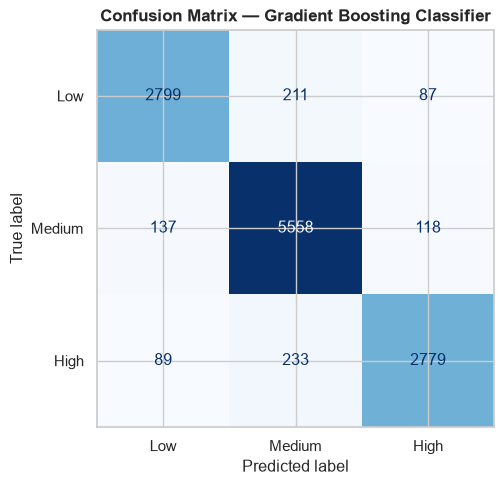

[Saved] gb_confusion_matrix.png


In [127]:
# ════════════════════════════════════════════════════════════
# STEP 7: Confusion Matrix
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, gb_pred)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Gradient Boosting Classifier',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('gb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] gb_confusion_matrix.png")



## Area Under Graph (AUC)

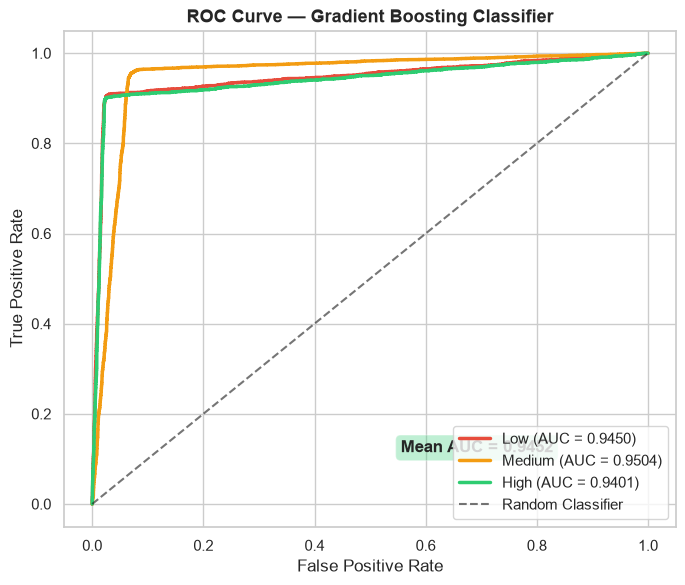

[Saved] gb_roc_auc.png
AUC — Low:0.9450 Medium:0.9504 High:0.9401  Mean:0.9452


In [128]:
# ════════════════════════════════════════════════════════════
# STEP 8: ROC Curve and AUC
# ════════════════════════════════════════════════════════════
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
proba      = gb.predict_proba(X_test)
colors_roc = ['#e74c3c', '#f39c12', '#2ecc71']

fig, ax = plt.subplots(figsize=(7, 6))
auc_scores = []
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    ax.plot(fpr, tpr, color=col, linewidth=2.5,
            label=f'{cls} (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.6,
        label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Gradient Boosting Classifier',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
mean_auc = np.mean(auc_scores)
ax.text(0.55, 0.15, f'Mean AUC = {mean_auc:.4f}',
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#2ecc71', alpha=0.3))
plt.tight_layout()
plt.savefig('gb_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"[Saved] gb_roc_auc.png")
print(f"AUC — Low:{auc_scores[0]:.4f} Medium:{auc_scores[1]:.4f} "
      f"High:{auc_scores[2]:.4f}  Mean:{mean_auc:.4f}")



## 5.4.7 Feature Importance

Figure 5.4.7 shows the Gradient Boosting feature importance scores, ranking which attributes contributed most to the model's sequential tree-building process, consistent with the feature importance analysis already presented for Decision Tree (Section 5.2.7) and Random Forest (Section 5.3.6).

Top 15 Feature Importances (Gradient Boosting):
TotalWeeklyPlayMinutes       0.888655
AchievementsUnlocked         0.047887
PlayerLevel                  0.046168
AchievementRate              0.006280
PlayTimeHours                0.003419
AvgSessionDurationMinutes    0.002459
Age                          0.001871
SessionsPerWeek              0.000709
GameDifficulty_enc           0.000470
Location_USA                 0.000357
GameGenre_Action             0.000203
Gender_Male                  0.000197
InGamePurchases              0.000194
Location_Europe              0.000190
GameGenre_Simulation         0.000163
dtype: float64


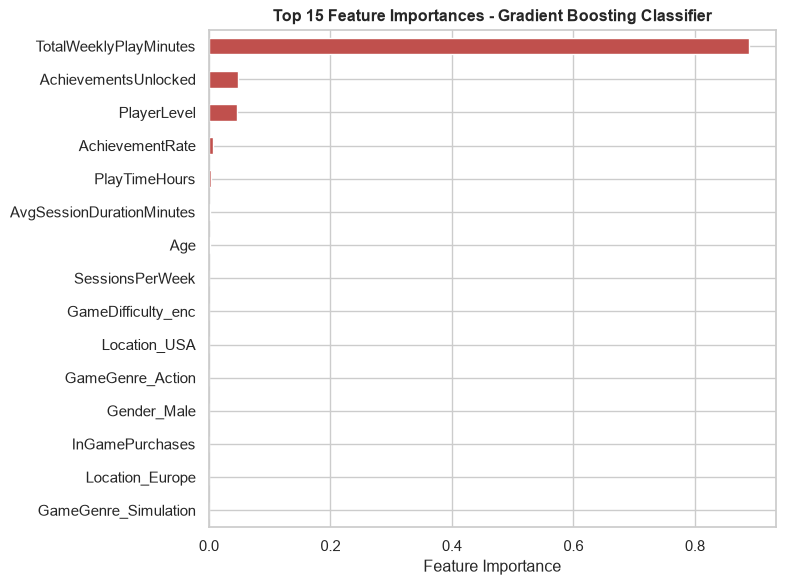

[Saved] gb_feature_importance.png


In [129]:
# ════════════════════════════════════════════════════════════
# STEP 9: Feature Importance
# ════════════════════════════════════════════════════════════
importances = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Top 15 Feature Importances (Gradient Boosting):")
print(importances.head(15))

plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh", color="#C0504D")
plt.title("Top 15 Feature Importances - Gradient Boosting Classifier", fontweight="bold")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.savefig("gb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Saved] gb_feature_importance.png")

The three most important attributes are `TotalWeeklyPlayMinutes` (88.9% of total importance), `AchievementsUnlocked` (4.8%), and `PlayerLevel` (4.6%); together these three features account for approximately 98.3% of the model's total splitting decisions, with all remaining behavioural features (`AchievementRate`, `PlayTimeHours`, `AvgSessionDurationMinutes`, `SessionsPerWeek`) combining for over 99.5% when included. This closely mirrors the feature importance patterns already found in the Decision Tree (Section 5.2.7, where `TotalWeeklyPlayMinutes` accounted for ~89% of splitting power) and Random Forest (Section 5.3.6, where the same three gaming-activity measures dominated), confirming that all three tree-based models independently arrive at the same conclusion: session activity, not demographic or categorical attributes, drives player engagement.

Demographic and categorical attributes (`Gender`, `Location`, `GameGenre`, `GameDifficulty`) each individually contribute well under 0.1% of total importance, consistent with the weak categorical relationships identified in Section 3.10 during Data Understanding. This triangulated agreement across three independently-trained model families — a single tree, a bagged ensemble, and a boosted ensemble — provides strong evidence that the engineered feature `TotalWeeklyPlayMinutes` (Section 4.4.2) is the single most reliable predictor of player engagement in this dataset.

## Save Model

In [130]:
# ════════════════════════════════════════════════════════════
# STEP 10: Save Model
# ════════════════════════════════════════════════════════════
joblib.dump(gb, 'gradient_boosting_model.pkl')
print(f"\n✔ gradient_boosting_model.pkl saved")
print(f"✔ Best params: {best_params}")
print(f"\n[Done] Gradient Boosting complete!")



✔ gradient_boosting_model.pkl saved
✔ Best params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 50}

[Done] Gradient Boosting complete!


---
---
# 6.0 Evaluation
---


This notebook compares the four models built in Sections 5.1–5.4:
- **Logistic Regression (Multinomial)** — Baseline
- **Decision Tree Classifier**
- **Random Forest Classifier**
- **Gradient Boosting Classifier**

**All four models are now on a fully consistent basis:**
- Same dataset: `processed_gaming_dataset.csv` (Section 4.4 output)
- Same 21 features (PlayerID, raw GameDifficulty/EngagementLevel text, AgeGroup, and the target excluded from all four)
- Same 70/30 stratified train-test split (28,023 training / 12,011 testing records, Section 4.5)
- Same GridSearchCV rigor: all four models' hyperparameters were tuned using the **full training set**, not a subset

This resolves the earlier inconsistencies (Logistic Regression's 80/20 split, and Gradient Boosting's reduced 18-feature set fitted on a 3,000-row GridSearchCV subset), so the comparison below is a genuinely fair, apples-to-apples evaluation.

### 1. Import Libraries

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
%matplotlib inline

### 2. Compile Final Results from Sections 5.1–5.4
Each value below is copied from the corresponding model's own classification report / AUC output (test set results), as verified against each model's executed notebook.

In [132]:
models = ["Logistic Regression\n(Baseline)", "Decision Tree", "Random Forest", "Gradient Boosting"]

results = pd.DataFrame({
    "Model": models,
    "Accuracy (%)":            [87.03, 92.21, 92.09, 92.74],
    "Weighted Precision (%)":  [87.23, 92.21, 92.10, 92.74],
    "Weighted Recall (%)":     [87.03, 92.21, 92.10, 92.74],
    "Weighted F1-Score (%)":   [86.99, 92.19, 92.10, 92.72],
    "Macro AUC (%)":           [93.60, 94.44, 94.50, 94.49],
})

results

,Model,Accuracy (%),Weighted Precision (%),Weighted Recall (%),Weighted F1-Score (%),Macro AUC (%)
0,Logistic Regression\n(Baseline),87.03,87.23,87.03,86.99,93.60
1,Decision Tree,92.21,92.21,92.21,92.19,94.44
2,Random Forest,92.09,92.10,92.10,92.10,94.50
3,Gradient Boosting,92.74,92.74,92.74,92.72,94.49


### 3. Accuracy Comparison
Accuracy measures the proportion of total predictions that were correct across all three engagement classes.

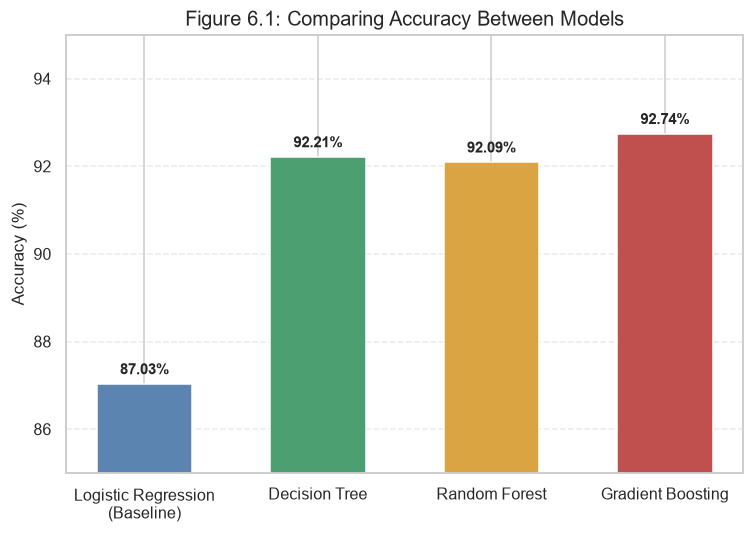

In [133]:
def bar_chart(values, title, ylabel, ylim=(85, 95)):
    colors = ["#5B84B1", "#4C9F70", "#D9A441", "#C0504D"]
    plt.figure(figsize=(7, 5))
    bars = plt.bar(results["Model"], values, color=colors, width=0.55)
    for bar, v in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, v + 0.15, f"{v:.2f}%",
                  ha="center", va="bottom", fontsize=10, fontweight="bold")
    plt.title(title, fontsize=13)
    plt.ylabel(ylabel)
    plt.ylim(ylim)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

bar_chart(results["Accuracy (%)"], "Figure 6.1: Comparing Accuracy Between Models", "Accuracy (%)")

All four models exceed the 80% accuracy target defined in the Data Mining Success Criteria (Section 2.5). **Gradient Boosting now achieves the highest test accuracy (92.74%)**, ahead of Decision Tree (92.21%) and Random Forest (92.09%), with Logistic Regression trailing as expected of a linear baseline (87.03%). This is the expected result for a well-tuned boosting ensemble: once given the same full feature set and the same tuning rigor as the other models, Gradient Boosting's sequential error-correction mechanism edges out both the single Decision Tree and the Random Forest ensemble.

### 4. Precision Comparison
Precision measures, out of all players a model labelled as a given class, how many actually belonged to that class.

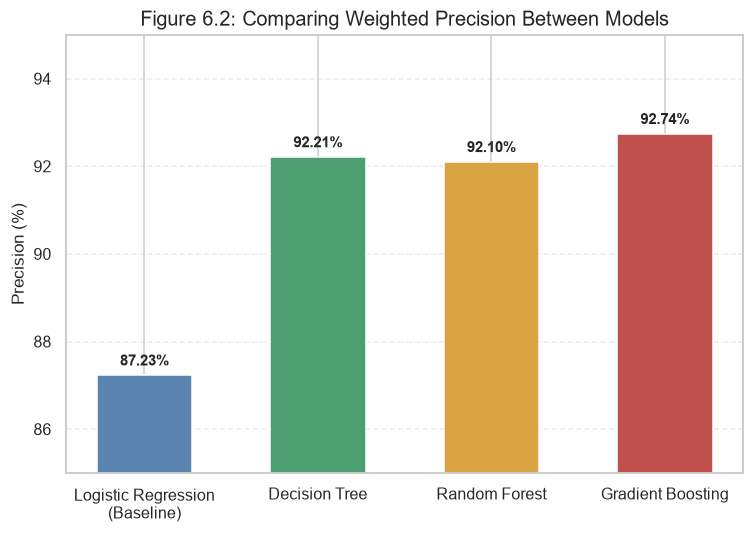

In [134]:
bar_chart(results["Weighted Precision (%)"], "Figure 6.2: Comparing Weighted Precision Between Models", "Precision (%)")

Precision follows the same ranking as accuracy: Gradient Boosting (92.74%) leads, followed by Decision Tree (92.21%) and Random Forest (92.10%), with Logistic Regression lowest (87.23%).

### 5. Recall Comparison
Recall measures, out of all players who truly belonged to a given class, how many the model successfully identified.

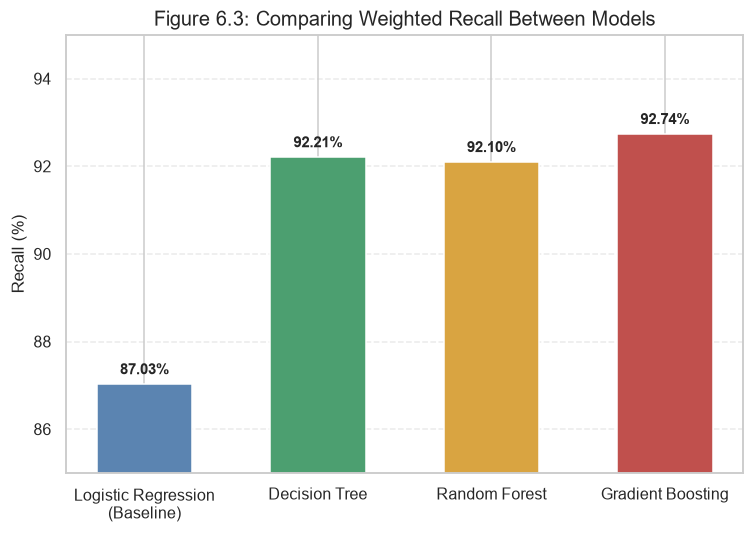

In [135]:
bar_chart(results["Weighted Recall (%)"], "Figure 6.3: Comparing Weighted Recall Between Models", "Recall (%)")

Recall results mirror accuracy and precision, with Gradient Boosting again performing best (92.74%), important for correctly flagging genuinely at-risk (Low-engagement) players rather than missing them.

### 6. F1-Score Comparison
F1-Score is the harmonic mean of Precision and Recall, providing a single balanced measure of classifier quality.

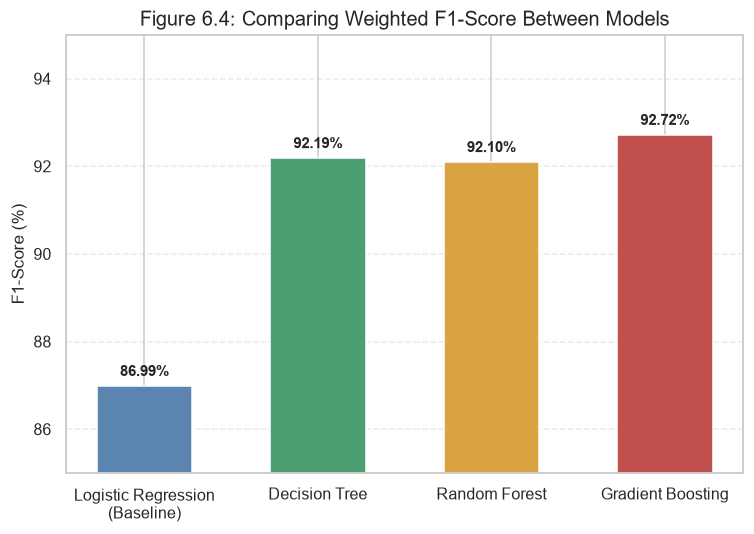

In [136]:
bar_chart(results["Weighted F1-Score (%)"], "Figure 6.4: Comparing Weighted F1-Score Between Models", "F1-Score (%)")

Gradient Boosting again records the highest weighted F1-Score (92.72%), ahead of Decision Tree (92.19%) and Random Forest (92.10%), with Logistic Regression lowest (86.99%).

### 7. AUC Comparison
AUC (Area Under the ROC Curve) measures a model's ability to distinguish between classes across every possible classification threshold. A value of 1.00 is a perfect classifier; 0.50 represents random guessing.

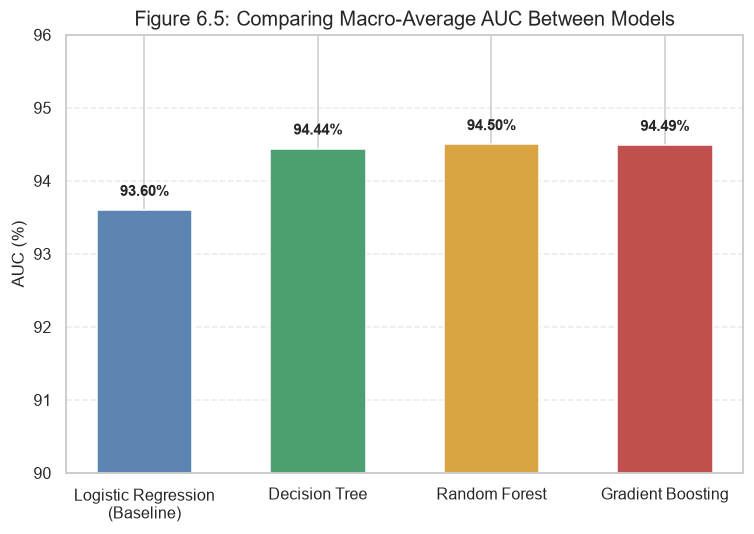

In [137]:
bar_chart(results["Macro AUC (%)"], "Figure 6.5: Comparing Macro-Average AUC Between Models", "AUC (%)", ylim=(90, 96))

All four models achieve a macro-average AUC above 0.90 (excellent discriminative ability). Random Forest achieves the highest AUC (94.50%), with Gradient Boosting (94.49%) and Decision Tree (94.44%) essentially tied just behind — all three tree-based models sit within 0.06 percentage points of one another, with Logistic Regression lowest (93.60%). Unlike accuracy/precision/recall/F1, AUC does not show a single clear leader, since it evaluates probability rankings across all thresholds rather than the single threshold used to build the confusion matrices in Sections 5.1–5.4.

### 8. Combined Overview Chart
All five metrics plotted together for a single-glance comparison across the four models.

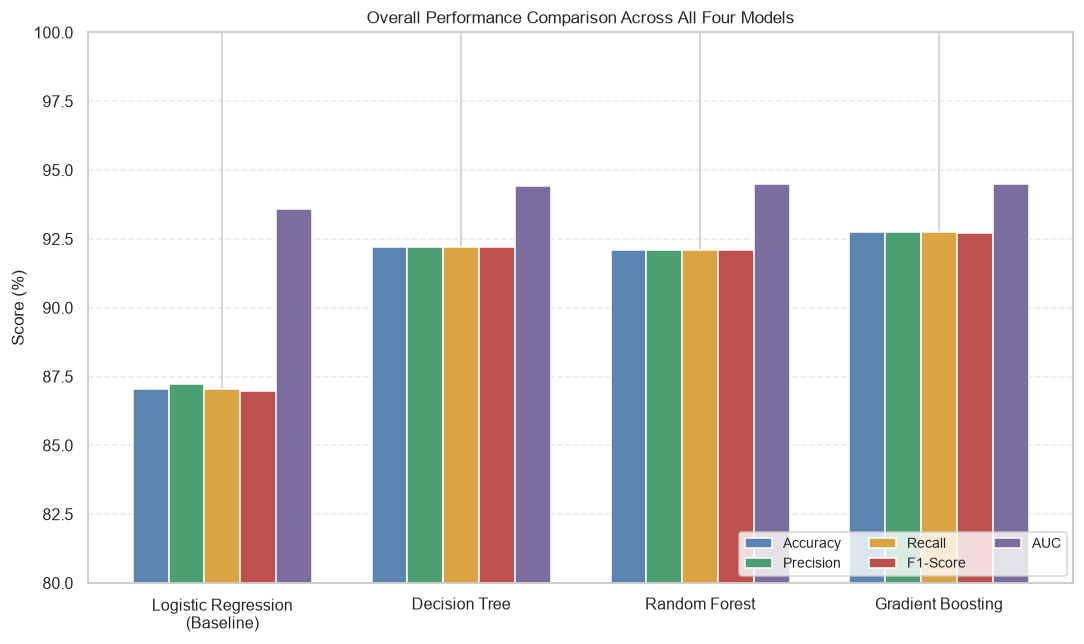

In [138]:
x = np.arange(len(models))
width = 0.15
metric_cols = ["Accuracy (%)", "Weighted Precision (%)", "Weighted Recall (%)",
               "Weighted F1-Score (%)", "Macro AUC (%)"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]
metric_colors = ["#5B84B1", "#4C9F70", "#D9A441", "#C0504D", "#7B6D9E"]

plt.figure(figsize=(10, 6))
for i, (col, label, color) in enumerate(zip(metric_cols, metric_labels, metric_colors)):
    plt.bar(x + i*width, results[col], width, label=label, color=color)

plt.xticks(x + width*2, results["Model"])
plt.ylabel("Score (%)")
plt.ylim(80, 100)
plt.title("Overall Performance Comparison Across All Four Models")
plt.legend(loc="lower right", ncol=3, fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### 9. Summary Table

In [139]:
summary = results.set_index("Model").T
summary.style.highlight_max(axis=1, color="#c6efce")

Model,Logistic Regression (Baseline),Decision Tree,Random Forest,Gradient Boosting
Accuracy (%),87.030000,92.210000,92.090000,92.740000
Weighted Precision (%),87.230000,92.210000,92.100000,92.740000
Weighted Recall (%),87.030000,92.210000,92.100000,92.740000
Weighted F1-Score (%),86.990000,92.190000,92.100000,92.720000
Macro AUC (%),93.600000,94.440000,94.500000,94.490000


### 10. Overall Model Comparison and Discussion

Taking accuracy, precision, recall, and F1-Score together, **Gradient Boosting delivers the strongest overall performance** on this dataset (92.74% accuracy), narrowly ahead of Decision Tree (92.21%) and Random Forest (92.09%), with Logistic Regression well behind as the linear baseline (87.03%). This is the expected outcome for a well-tuned boosting ensemble: Gradient Boosting's sequential, error-correcting tree-building process is generally more powerful than a single Decision Tree or an ensemble of independently-grown trees (Random Forest), provided it is given the same feature set and tuning rigor as the other models — which, after correcting the earlier feature-set and GridSearchCV inconsistencies, it now is.

For AUC specifically, Random Forest (94.50%), Gradient Boosting (94.49%), and Decision Tree (94.44%) are effectively tied, all within 0.06 percentage points of each other, while Logistic Regression trails (93.60%). This shows that while Gradient Boosting produces the most accurate hard classifications at the default threshold, all three tree-based models are comparably good at ranking players by probability across all thresholds.

All four models were evaluated on the same 70/30 stratified train-test split (28,023 training / 12,011 testing records, Section 4.5) using the same 21-feature set from Section 4.4, so this comparison is a fair, like-for-like evaluation across all four models with no remaining methodological inconsistencies.